In [2]:
#Importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('pdb_data_no_dups.csv')# asignamos
df

,structureId,classification,experimentalTechnique,macromoleculeType,residueCount,resolution,structureMolecularWeight,crystallizationMethod,crystallizationTempK,densityMatthews,densityPercentSol,pdbxDetails,phValue,publicationYear
0,5I87,LIGASE,X-RAY DIFFRACTION,Protein,1385,3.70,118468.38,"VAPOR DIFFUSION, SITTING DROP",292.15,NaN,NaN,"MES, tri-potassium citrate, PEG10000",6.0,2016.0
1,4CAT,OXIDOREDUCTASE(H2O2(A)),X-RAY DIFFRACTION,Protein,1318,3.00,113437.46,NaN,NaN,3.59,65.73,NaN,NaN,1986.0
2,4KZP,OXIDOREDUCTASE,X-RAY DIFFRACTION,Protein,1280,1.68,132516.84,"VAPOR DIFFUSION, SITTING DROP",289.00,2.52,51.23,"25% PEG3350, 0.1M BisTris-HCl, pH=6.5 0.2M NaC...",6.5,NaN
3,1TAH,HYDROLASE(CARBOXYLIC ESTERASE),X-RAY DIFFRACTION,Protein,1272,3.00,132346.81,NaN,NaN,3.01,59.08,NaN,NaN,1993.0
4,4I1Y,TRANSFERASE,X-RAY DIFFRACTION,Protein,1256,2.60,131584.55,"VAPOR DIFFUSION, SITTING DROP",298.00,2.66,53.70,"27.42 mg/ml MyulA.01147.b, 20% PEG3350, 200mM ...",6.5,2015.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115988,1RR1,RHINOVIRUS COAT PROTEIN,X-RAY DIFFRACTION,NaN,0,NaN,356.46,NaN,NaN,NaN,NaN,NaN,NaN,1988.0
115989,1R07,RHINOVIRUS COAT PROTEIN,X-RAY DIFFRACTION,NaN,0,NaN,348.82,NaN,NaN,NaN,NaN,NaN,NaN,1988.0
115990,1R04,RHINOVIRUS COAT PROTEIN,X-RAY DIFFRACTION,NaN,0,NaN,342.43,NaN,NaN,NaN,NaN,NaN,NaN,1988.0
115991,1RS5,RHINOVIRUS COAT PROTEIN,X-RAY DIFFRACTION,NaN,0,NaN,328.40,NaN,NaN,NaN,NaN,NaN,NaN,1988.0


In [4]:
df.dropna(subset=['crystallizationTempK','densityMatthews','phValue','resolution'], inplace=True)


In [5]:
# Suponiendo que tu DataFrame se llama df y la columna es 'experimentalTechnique'
valores_unicos = df['experimentalTechnique'].unique()

# Ahora, valores_unicos contiene los valores únicos en la columna 'experimentalTechnique'
print(valores_unicos)


['X-RAY DIFFRACTION' 'X-RAY DIFFRACTION, EPR' 'NEUTRON DIFFRACTION'
 'SOLUTION SCATTERING, X-RAY DIFFRACTION'
 'NEUTRON DIFFRACTION, X-RAY DIFFRACTION' 'ELECTRON CRYSTALLOGRAPHY'
 'EPR, X-RAY DIFFRACTION' 'POWDER DIFFRACTION'
 'X-RAY DIFFRACTION, NEUTRON DIFFRACTION']


In [6]:
# Suponiendo que tu DataFrame se llama df y la columna es 'experimentalTechnique'
valores_unicos = df['macromoleculeType'].unique()

# Ahora, valores_unicos contiene los valores únicos en la columna 'experimentalTechnique'
print(valores_unicos)


['Protein' nan 'Protein#DNA' 'Protein#RNA' 'Protein#DNA#RNA'
 'Protein#DNA#DNA/RNA Hybrid' 'Protein#DNA/RNA Hybrid' 'RNA'
 'RNA#DNA/RNA Hybrid' 'DNA' 'DNA#RNA' 'DNA/RNA Hybrid'
 'DNA#DNA/RNA Hybrid']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 96119 entries, 1 to 138012
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   structureId               96119 non-null  object 
 1   classification            96118 non-null  object 
 2   experimentalTechnique     96119 non-null  object 
 3   macromoleculeType         94150 non-null  object 
 4   residueCount              96119 non-null  int64  
 5   resolution                96051 non-null  float64
 6   structureMolecularWeight  96119 non-null  float64
 7   crystallizationMethod     93374 non-null  object 
 8   crystallizationTempK      96119 non-null  float64
 9   densityMatthews           94844 non-null  float64
 10  densityPercentSol         94835 non-null  float64
 11  pdbxDetails               96051 non-null  object 
 12  phValue                   86097 non-null  float64
 13  publicationYear           77329 non-null  float64
dtypes: fl

In [ ]:
pip install fancyimpute


  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 5.2 MB/s eta 0:00:00
  Created wheel for fancyimpute: filename=fancyimpute-0.7.0-py3-none-any.whl size=29880 sha256=9b8bb6e5f03801cae62184546d774d25d3b9709c050550a805d92164e87f8df9
  Stored in directory: /root/.cache/pip/wheels/7b/0c/d3/ee82d1fbdcc0858d96434af108608d01703505d453720c84ed
  Created wheel for knnimpute: filename=knnimpute-0.1.0-py3-none-any.whl size=11329 sha256=61943d44c07d9a311140eeea64222a7e1c854d6bc2f1eabc7a98aabb6281a3e4
  Stored in directory: /root/.cache/pip/wheels/46/06/a5/45a724630562413c374e29c08732411d496092408b3a7bf754
Successfully built fancyimpute knnimpute


In [ ]:
from fancyimpute import KNN

# Columnas a imputar
columnas_a_imputar = ['crystallizationTempK', 'residueCount',
                      'densityMatthews', 'densityPercentSol', 'phValue','structureMolecularWeight']

# Imputación usando K-Nearest Neighbors para las columnas seleccionadas
df[columnas_a_imputar] = KNN(k=3).fit_transform(df[columnas_a_imputar])


In [ ]:
# Miramos los Registros nulos del dataframe
df.isna().sum()

structureId                     0
classification                  0
experimentalTechnique           0
macromoleculeType            1084
residueCount                    0
resolution                      0
structureMolecularWeight        0
crystallizationMethod        2070
crystallizationTempK            0
densityMatthews                 0
densityPercentSol              10
pdbxDetails                    19
phValue                         0
publicationYear             14301
dtype: int64

In [ ]:
#Creamos una copia de seguridad
df_clean = df.copy()

In [ ]:
# Lista de columnas para las que quieres llenar los valores faltantes con la moda
columnas_a_limpiar = ['crystallizationTempK', 'crystallizationMethod','macromoleculeType', 'resolution',
                      'densityMatthews', 'densityPercentSol', 'pdbxDetails', 'phValue', 'classification']

for columna in columnas_a_limpiar:
    # Calcular la moda de la columna
    moda = df_clean[columna].mode()[0]
    print(f'La moda de la columna {columna} es: {moda}')

    # Llenar los valores faltantes con la moda
    df_clean[columna].fillna(moda, inplace=True)


La moda de la columna crystallizationTempK es: 293.0
La moda de la columna crystallizationMethod es: VAPOR DIFFUSION, HANGING DROP
La moda de la columna macromoleculeType es: Protein
La moda de la columna resolution es: 2.0
La moda de la columna densityMatthews es: 2.2
La moda de la columna densityPercentSol es: 50.0
La moda de la columna pdbxDetails es: 0.1M bis-tris pH 7.0 -- 30% PEG3350
La moda de la columna phValue es: 7.5
La moda de la columna classification es: HYDROLASE


In [ ]:
# Miramos los Registros nulos del dataframe de nuevo
df.isna().sum()

structureId                     0
classification                  0
experimentalTechnique           0
macromoleculeType            1084
residueCount                    0
resolution                      0
structureMolecularWeight        0
crystallizationMethod        2070
crystallizationTempK            0
densityMatthews                 0
densityPercentSol              10
pdbxDetails                    19
phValue                         0
publicationYear             14301
dtype: int64

In [ ]:
df_clean

,structureId,classification,experimentalTechnique,macromoleculeType,residueCount,resolution,structureMolecularWeight,crystallizationMethod,crystallizationTempK,densityMatthews,densityPercentSol,pdbxDetails,phValue,publicationYear
2,4KZP,OXIDOREDUCTASE,X-RAY DIFFRACTION,Protein,1280,1.68,132516.84,"VAPOR DIFFUSION, SITTING DROP",289.0,2.52,51.23,"25% PEG3350, 0.1M BisTris-HCl, pH=6.5 0.2M NaC...",6.5,NaN
4,4I1Y,TRANSFERASE,X-RAY DIFFRACTION,Protein,1256,2.60,131584.55,"VAPOR DIFFUSION, SITTING DROP",298.0,2.66,53.70,"27.42 mg/ml MyulA.01147.b, 20% PEG3350, 200mM ...",6.5,2015.0
5,4E0B,OXIDOREDUCTASE,X-RAY DIFFRACTION,Protein,1252,2.17,130866.91,NaN,295.0,2.29,46.31,Protein: 3.3 mg/mL. Crystallization conditions...,7.0,NaN
6,1IE3,OXIDOREDUCTASE,X-RAY DIFFRACTION,Protein,1248,2.50,131994.33,"VAPOR DIFFUSION, HANGING DROP",297.0,2.51,50.91,"NaCacodylate, PEG 4000, Ammonium Acetate, pH 6...",6.5,2001.0
7,1IB6,OXIDOREDUCTASE,X-RAY DIFFRACTION,Protein,1248,2.10,131819.22,"VAPOR DIFFUSION, HANGING DROP",291.0,2.49,50.55,"TRIS-MALEATE, PEG 3350, AMMONIUM SULFATE, pH 6...",6.0,2001.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115499,3PPD,PROTEIN FIBRIL,X-RAY DIFFRACTION,Protein,6,1.50,683.10,"VAPOR DIFFUSION, HANGING DROP",298.0,1.55,20.39,"0.1M MES pH6.0, 0.2M Zn(OAc)2, 10%(w/v)PEG-800...",6.0,2011.0
115503,4XFO,PROTEIN FIBRIL,X-RAY DIFFRACTION,Protein,6,1.35,603.66,"VAPOR DIFFUSION, HANGING DROP",298.0,1.35,6.22,"0.2 M Ammonium sulfate, 0.1 M BIS-TRIS pH 5.5,...",5.5,2015.0
115517,4QXX,PROTEIN FIBRIL,X-RAY DIFFRACTION,Protein,5,1.45,488.54,"VAPOR DIFFUSION, HANGING DROP",291.0,1.46,15.94,"2 M ammonium sulfate, 0.1 M phosphate/citrate,...",4.2,2015.0
115984,415D,DNA,X-RAY DIFFRACTION,NaN,0,1.04,861.47,"VAPOR DIFFUSION, HANGING DROP",298.0,1.67,26.00,NaN,4.5,1998.0


In [ ]:
df=df_clean

structureMolecularWeight
residueCount
resolution
crystallizationTempK
densityMatthews
densityPercentSol
phValue

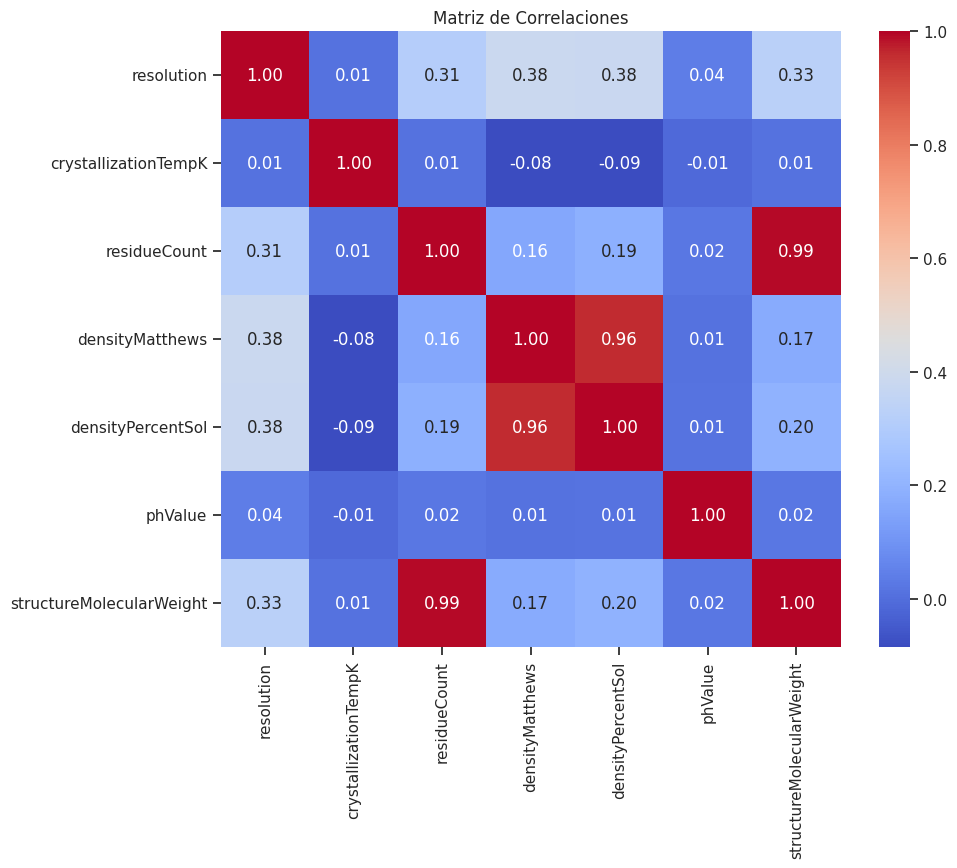

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Variables de interés
variables_of_interest = ['resolution',"crystallizationTempK", "residueCount", "densityMatthews", "densityPercentSol", "phValue", "structureMolecularWeight"]

# Crear una matriz de características (X) con las variables de interés
X = df[variables_of_interest]

# Calcular la matriz de correlaciones
correlation_matrix = X.corr()

# Crear un mapa de calor para visualizar la matriz de correlaciones
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlaciones')
plt.show()


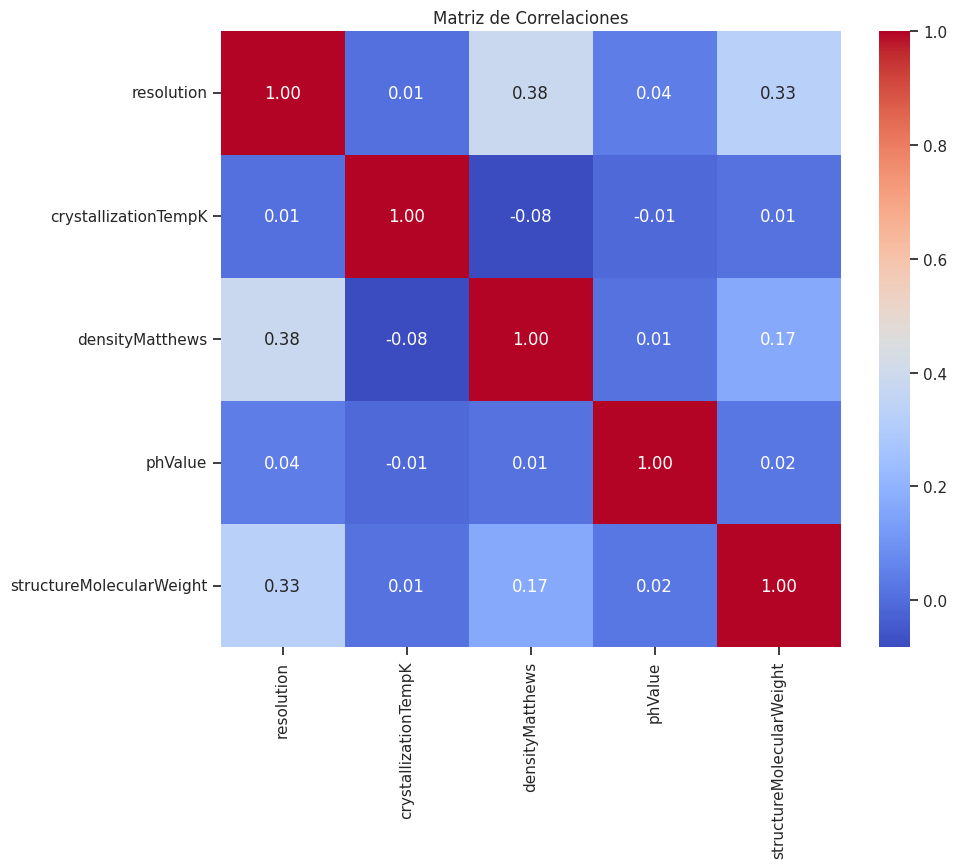

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Variables de interés
variables_of_interest = ['resolution',"crystallizationTempK", "densityMatthews", "phValue", "structureMolecularWeight"]

# Crear una matriz de características (X) con las variables de interés
X = df[variables_of_interest]

# Calcular la matriz de correlaciones
correlation_matrix = X.corr()

# Crear un mapa de calor para visualizar la matriz de correlaciones
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlaciones')
plt.show()

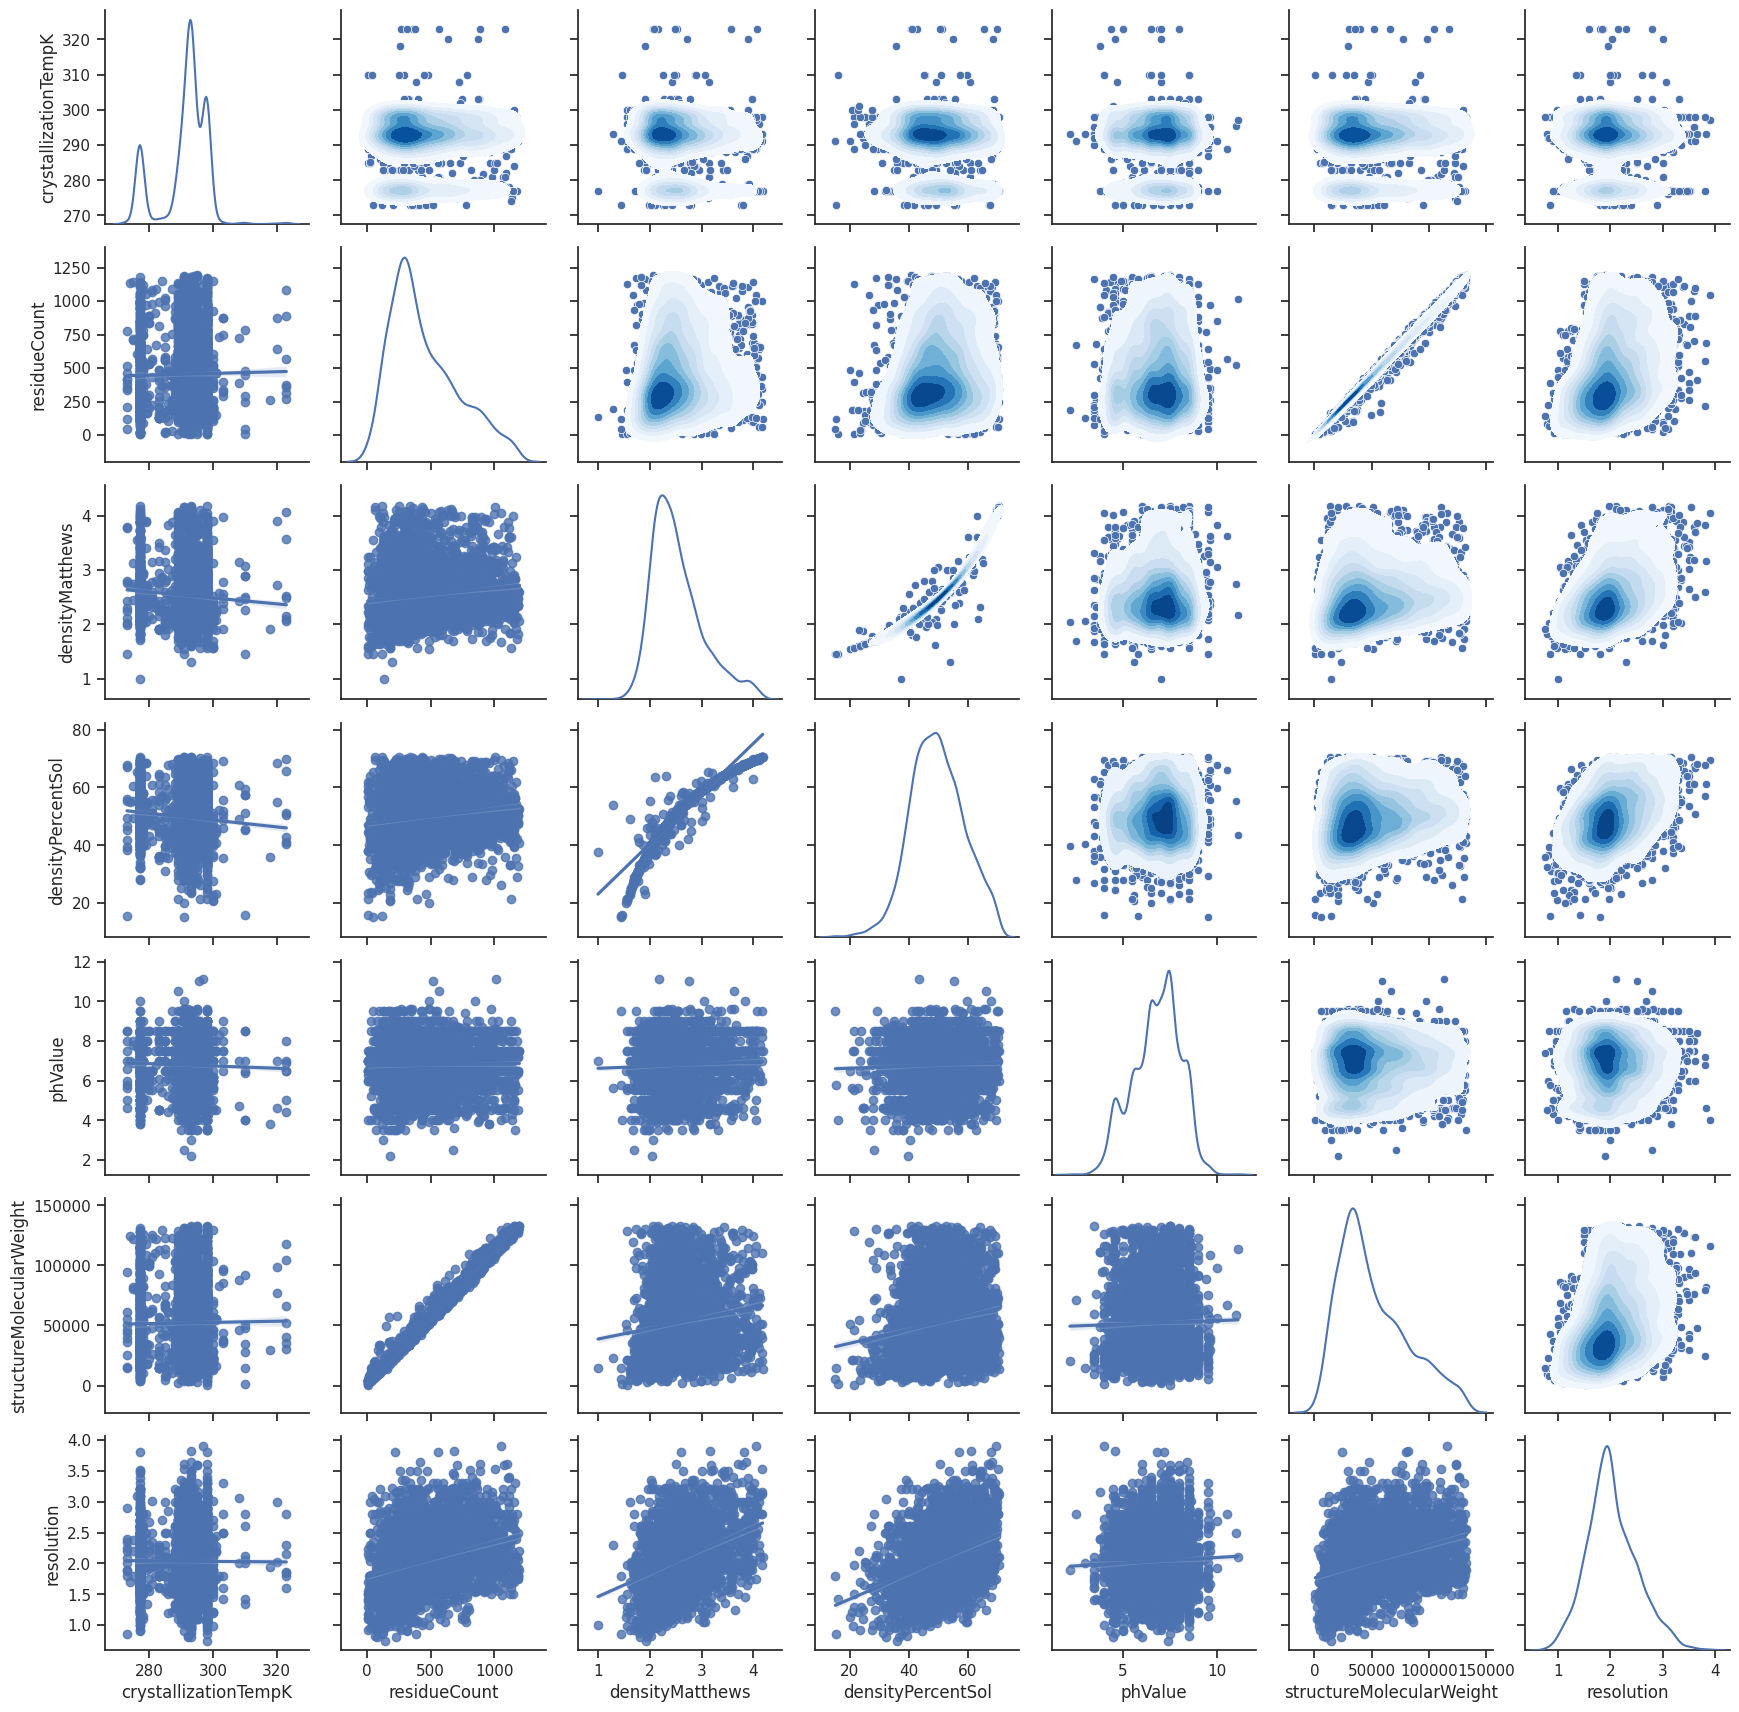

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Variables de interés
variables_of_interest = ["crystallizationTempK", , "densityPercentSol", "phValue", "structureMolecularWeight", "resolution"]

# Crear una matriz de características (X) con las variables de interés
X = df[variables_of_interest]

# Muestrear aleatoriamente una fracción de tus datos (por ejemplo, el 10%)
sampled_data = X.sample(frac=0.05, random_state=42)

# Definir el gráfico
g = sns.PairGrid(sampled_data, diag_sharey=False)

# Mapa de dispersión en la parte superior derecha
g.map_upper(sns.scatterplot)

# KDE bivariado en la diagonal superior
g.map_upper(sns.kdeplot, fill=True, cmap="Blues")

# KDE univariado en la diagonal
g.map_diag(sns.kdeplot)

# Regresión lineal en la parte inferior izquierda
g.map_lower(sns.regplot)

# Mostrar el gráfico
plt.show()


In [5]:
# Supongamos que quieres dejar 50,000 datos menos al azar
numero_filas_a_dejar = len(df) - 400

# Selecciona aleatoriamente las filas que quieres conservar
filas_a_guardar = df.sample(n=numero_filas_a_dejar, random_state=42)

# Elimina las filas seleccionadas del DataFrame original
df = df.drop(filas_a_guardar.index)

# Ahora, df tiene 50,000 datos menos al azar


In [6]:
df

,structureId,classification,experimentalTechnique,macromoleculeType,residueCount,resolution,structureMolecularWeight,crystallizationMethod,crystallizationTempK,densityMatthews,densityPercentSol,pdbxDetails,phValue,publicationYear
302,4U2X,VIRAL PROTEIN,X-RAY DIFFRACTION,Protein,1173,3.15,131767.08,"VAPOR DIFFUSION, HANGING DROP",298.0,3.95,68.85,"3.5M ammonium chloride, 0.1 M Bis-Tris propane",7.00,2014.0
423,3GNW,TRANSFERASE,X-RAY DIFFRACTION,Protein,1162,2.39,130968.28,"VAPOR DIFFUSION, HANGING DROP",293.0,2.95,58.36,"5-8% PEG 6000, 100mM Mg-Salts, pH 6.75, VAPOR ...",6.75,2009.0
569,5VB0,TRANSFERASE,X-RAY DIFFRACTION,Protein,1152,2.69,130761.29,"VAPOR DIFFUSION, SITTING DROP",298.0,2.64,53.33,"FosA3, protein was concentrated to 9mg/ml and ...",6.95,2017.0
1097,3O3W,"Structural Genomics, Unknown function",X-RAY DIFFRACTION,Protein,1134,2.91,129511.77,NaN,277.0,2.49,50.52,"Protein solution: 100mM NaCl, 5mM DTT, 0.02% N...",5.00,NaN
1251,4KQR,Biosynthetic Protein/Antibiotic,X-RAY DIFFRACTION,Protein,1128,2.01,124589.69,"VAPOR DIFFUSION, SITTING DROP",293.0,2.76,55.41,"2.5 M NaCl; 0.1 M imidazole , pH 8.0, VAPOR DI...",8.00,2013.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110541,2BEE,RNA/antibiotic,X-RAY DIFFRACTION,RNA,44,2.60,15528.10,"VAPOR DIFFUSION, HANGING DROP",310.0,2.69,54.35,"MPD, KCl, MGSO4, GLYCEROL, Na Cacodylate, pH 6...",6.40,2004.0
110861,4LH9,TRANSCRIPTION,X-RAY DIFFRACTION,Protein,40,2.05,4719.38,"VAPOR DIFFUSION, HANGING DROP",289.0,3.25,62.12,"0.15M NaAc, 0.1M Nacacodylate, 27% PEG8000, pH...",6.50,NaN
112699,3CO3,DNA,X-RAY DIFFRACTION,DNA,24,2.16,7670.48,"VAPOR DIFFUSION, HANGING DROP",277.0,2.93,58.04,"120 mM Mg(acetate), 50 mM Na cacodylate, 1 mM ...",6.50,2008.0
112775,460D,DNA,X-RAY DIFFRACTION,DNA,24,1.20,7521.15,"VAPOR DIFFUSION, SITTING DROP",275.0,2.23,44.84,SITTING DROPLETS CONTAINING 1.2 MM OLIGONUCLEO...,6.90,1999.0


<Figure size 640x480 with 0 Axes>

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


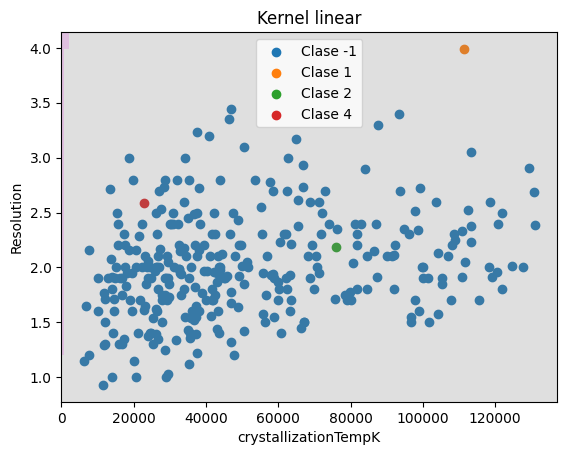

<Figure size 640x480 with 0 Axes>

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


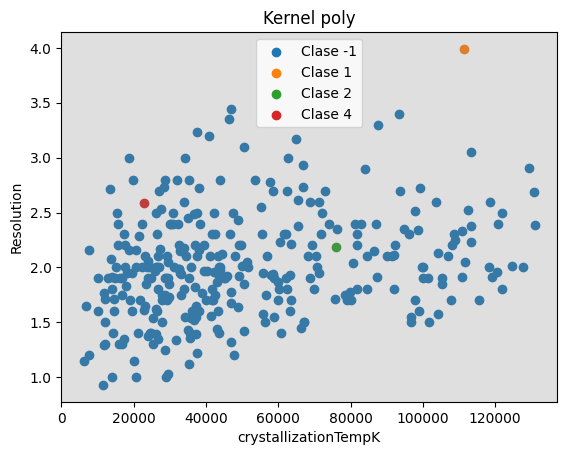

<Figure size 640x480 with 0 Axes>

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


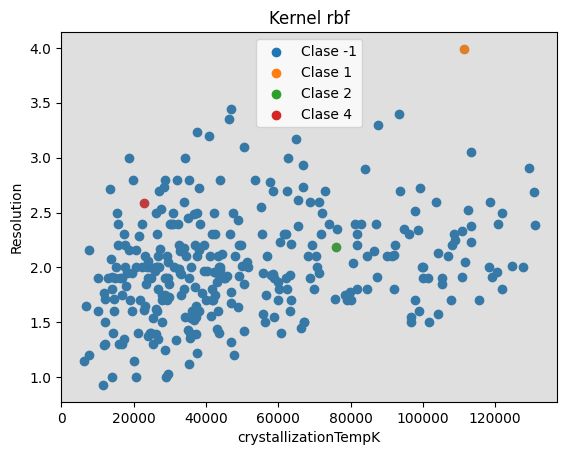

<Figure size 640x480 with 0 Axes>

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


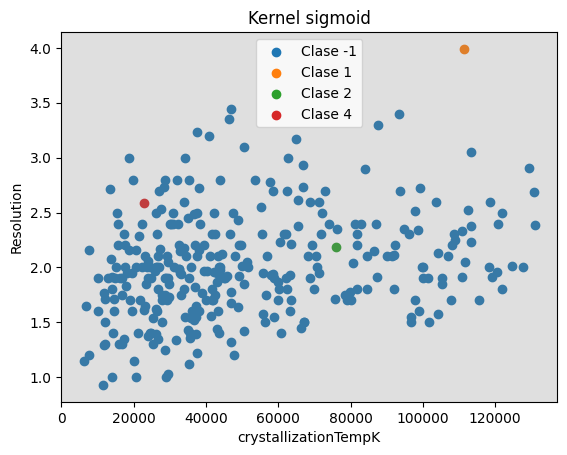

linear


ValueError: ignored

<Figure size 640x480 with 0 Axes>

In [7]:
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

def DibujaDatos(X, y):
    # X: Características.
    # y: Etiquetas.

    plt.figure()
    for clase in np.unique(y):
        X_clase = X[y == clase]
        plt.scatter(X_clase[:, 0], X_clase[:, 1], label=f'Clase {clase}')

    plt.xlabel('Ingresos (miles euros)')
    plt.ylabel('Edad (años)')
    plt.legend()

def DrawRegionesSVM(X, y, kernel):
    # X: Características.
    # y: Etiquetas.
    # kernel: Kernel a utilizar en el clasificador.

    modelo = OptimizaModelo(X, y, kernel)
    DibujaDatos(X, y)

    x1lim = plt.xlim()
    x2lim = plt.ylim()
    ngrid = 100
    x1 = np.linspace(x1lim[0], x1lim[1], ngrid)
    x2 = np.linspace(x2lim[0], x2lim[1], ngrid)
    dx1 = (x1[1] - x1[0]) / 2
    dx2 = (x2[1] - x2[0]) / 2
    TablaColor = ('lightblue', 'pink', 'green', 'orange', 'purple', 'brown', 'gray')

    for i in range(ngrid):
        for j in range(ngrid):
            xi = np.array([[x1[i], x2[j]]])
            yi = modelo.predict(xi)
            x1p = [x1[i] - dx1, x1[i] + dx1, x1[i] + dx1, x1[i] - dx1]
            x2p = [x2[j] - dx2, x2[j] - dx2, x2[j] + dx2, x2[j] + dx2]
            color = TablaColor[int(yi[0])]
            plt.fill(x1p, x2p, color=color, alpha=0.25, edgecolor='none')  # Ajusta la transparencia aquí

    plt.xlabel('crystallizationTempK')
    plt.ylabel('Resolution')
    plt.xlim(x1lim)
    plt.ylim(x2lim)

def OptimizaModelo(X, y, kernel):
    # X: Características.
    # y: Etiquetas.
    # kernel: Kernel a utilizar en el clasificador.

    modelo = SVC(gamma='scale', kernel=kernel, degree=4)  # Grado 4 para el kernel polinómico
    modelo.fit(X, y)
    return modelo

def EvaluaModelo(X, y, modelo):
    # X: Características.
    # y: Etiquetas.
    # modelo: Modelo de SVM entrenado.

    ACC = modelo.score(X, y)  # Accuracy (exactitud) del modelo
    return ACC


def DibujaCurvaAprendizaje(X, y):
    # X: Matriz de diseño.
    # y: Vector de objetivos (target).

    npuntos = 100  # Nº de puntos de la curva de aprendizaje
    ntrain_vector = np.linspace(5, 600, npuntos)  # Nº clientes training (vector)
    ACCtest = np.zeros(npuntos)  # Reserva de espacio para el coste de testing
    kernel_vector = ['linear', 'poly', 'rbf', 'sigmoid']  # Agrega 'sigmoid' a la lista de kernels
    orden_vector = [0, 2, 0, 0]  # Ajusta el orden para el kernel sigmoidal
    label_vector = ['linear', 'poly2', 'gauss', 'sigmoid']  # Agrega 'sigmoid' a las etiquetas
    nkernel = len(kernel_vector)

    plt.figure()
    for ikernel in range(nkernel):
        kernel = kernel_vector[ikernel]
        print(kernel)
        orden = orden_vector[ikernel]
        label = label_vector[ikernel]
        for k in range(npuntos):
            # Itera para distintos valores de ntrain
            # Optimiza el modelo para el Training Dataset
            ntrain = ntrain_vector[k]
            ntrain = ntrain.astype('int')  # Lo convierte en un número entero
            Xtrain = X[:ntrain, :]  # Vector de características (training)
            ytrain = y[:ntrain]  # Vector de etiquetas (training)
            modelo = OptimizaModelo(Xtrain, ytrain, kernel)

            # Cálculo del coste para el Test Dataset
            Xtest = X[ntrain:, :]  # Vector de características (test)
            ytest = y[ntrain:]  # Vector de etiquetas (test)
            ACCtest[k] = EvaluaModelo(Xtest, ytest, modelo)  # Coste (test)

        # Dibujo de la curva de aprendizaje
        plt.plot(ntrain_vector, ACCtest, label=label)

    plt.xlabel('Número de datos para entrenamiento')
    plt.ylabel('Accuracy')
    plt.legend()

# Carga tus datos desde el archivo Excel.

# Mapea las etiquetas a valores consecutivos a partir de 0, excepto las únicas que tendrán un valor constante
y, _ = pd.factorize(df['macromoleculeType'])
y[df['macromoleculeType'].duplicated()] = -1  # Puedes usar cualquier otro valor que desees para las categorías únicas


# Resto del código...

# Mapea las etiquetas a valores consecutivos a partir de 0


# Características para la clasificación
X = df[['structureMolecularWeight', 'resolution']].values

# Partición de los datos en conjuntos de entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Lista de kernels a probar (incluyendo 'sigmoid')
kernels = ['linear', 'poly', 'rbf', 'sigmoid']

# Genera y muestra las gráficas para cada kernel
for kernel in kernels:
    plt.figure()
    DrawRegionesSVM(X_train, y_train, kernel)
    plt.title(f'Kernel {kernel}')
    plt.show()

# Muestra la curva de aprendizaje
DibujaCurvaAprendizaje(X_train, y_train)
plt.show()

In [19]:
# Verifica la cantidad de clases únicas en la columna 'experimentalTechnique'
num_clases = len(df['macromoleculeType'].unique())
print(f"Número de clases únicas: {num_clases}")


Número de clases únicas: 8


In [17]:
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

import warnings

# Opción 1: Mostrar las advertencias una vez
warnings.filterwarnings("ignore")


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Función para optimizar el modelo SVM
def OptimizaModelo(X, y, kernel):
    # X: Características.
    # y: Etiquetas.
    # kernel: Kernel a utilizar en el clasificador.

    modelo = SVC(gamma='scale', kernel=kernel, degree=4)  # Grado 4 para el kernel polinómico
    modelo.fit(X, y)
    return modelo

# Función para calcular una métrica (precisión, recuperación o F2 Score)
def CalculaMetrica(y_true, y_pred, metrica):
    if metrica == 'precision':
        score = precision_recall_fscore_support(y_true, y_pred, average='weighted')[0]
    elif metrica == 'recall':
        score = precision_recall_fscore_support(y_true, y_pred, average='weighted')[1]
    elif metrica == 'f2_score':
        score = precision_recall_fscore_support(y_true, y_pred, average='weighted', beta=2)[2]
    elif metrica == 'accuracy':
        score = accuracy_score(y_true, y_pred)
    return score

def DibujaCurvaMetrica(X_train, y_train, X_test, y_test, metrica):
    npuntos = 100
    ntrain_vector = np.linspace(5, len(X_train), npuntos).astype(int)
    scores = {metrica: []}
    kernel_vector = ['linear', 'poly', 'rbf', 'sigmoid']
    nkernel = len(kernel_vector)

    for ikernel in range(nkernel):
        kernel = kernel_vector[ikernel]
        print(f'Kernel: {kernel}')

        scores_kernel = {metrica: []}

        for ntrain in ntrain_vector:
            Xtrain = X_train[:ntrain, :]
            ytrain = y_train[:ntrain]
            modelo = OptimizaModelo(Xtrain, ytrain, kernel)
            y_pred = modelo.predict(X_test)
            metric_score = CalculaMetrica(y_test, y_pred, metrica)

            scores_kernel[metrica].append(metric_score)

        scores[metrica].append(scores_kernel[metrica])

    plt.figure(figsize=(12, 6))

    for i in range(nkernel):
        plt.plot(ntrain_vector, scores[metrica][i], label=f'Kernel {kernel_vector[i]}')

    plt.xlabel('Número de muestras de entrenamiento')
    plt.ylabel(metrica.capitalize())
    plt.title(f'Comportamiento de {metrica.capitalize()} por Kernel')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Métricas a calcular
metricas = ['accuracy', 'precision', 'recall', 'f2_score']

for metrica in metricas:
    DibujaCurvaMetrica(X_train, y_train, X_test, y_test, metrica)

Kernel: linear


ValueError: ignored

In [ ]:
# 1. Obtener valores únicos de la columna 'experimentalTechnique'
valores_unicos = df['experimentalTechnique'].unique()

# 2. Variables de interés
variables_of_interest = ["crystallizationTempK", "densityPercentSol", "phValue", "structureMolecularWeight", "resolution"]

# Crear una matriz de características (X) con las variables de interés
X = df[variables_of_interest]

# Resto del código permanece igual...

# Partición de los datos en conjuntos de entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Lista de kernels a probar (incluyendo 'sigmoid')
kernels = ['linear', 'poly', 'rbf', 'sigmoid']

# Genera y muestra las gráficas para cada kernel
for kernel in kernels:
    plt.figure()
    DrawRegionesSVM(X_train, y_train, kernel)
    plt.title(f'Kernel {kernel}')
    plt.show()

# Muestra la curva de aprendizaje
DibujaCurvaAprendizaje(X_train, y_train)
plt.show()

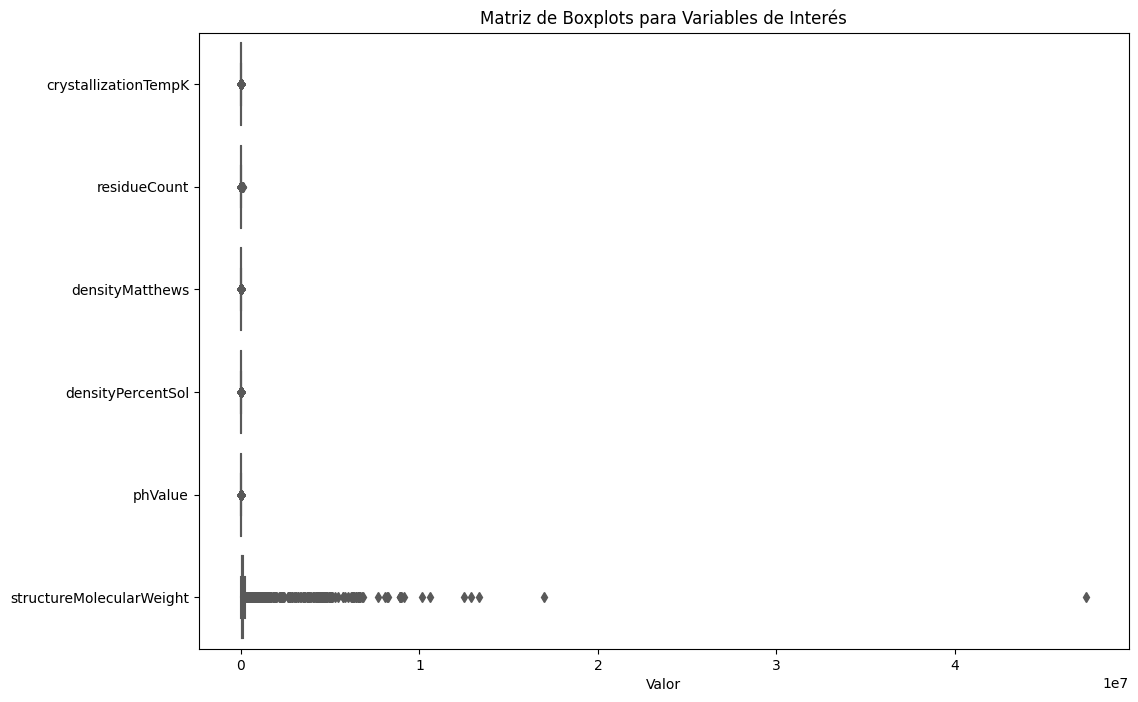

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Variables de interés
variables_of_interest = ["crystallizationTempK", "residueCount", "densityMatthews", "densityPercentSol", "phValue", "structureMolecularWeight"]

# Crear una matriz de características (X) con las variables de interés
X = df[variables_of_interest]

# Definir el tamaño del gráfico
plt.figure(figsize=(12, 8))

# Crear una matriz de boxplots
sns.boxplot(data=X, orient="h", palette="Set2")

# Añadir etiquetas y título
plt.xlabel("Valor")
plt.title("Matriz de Boxplots para Variables de Interés")

# Mostrar el gráfico
plt.show()


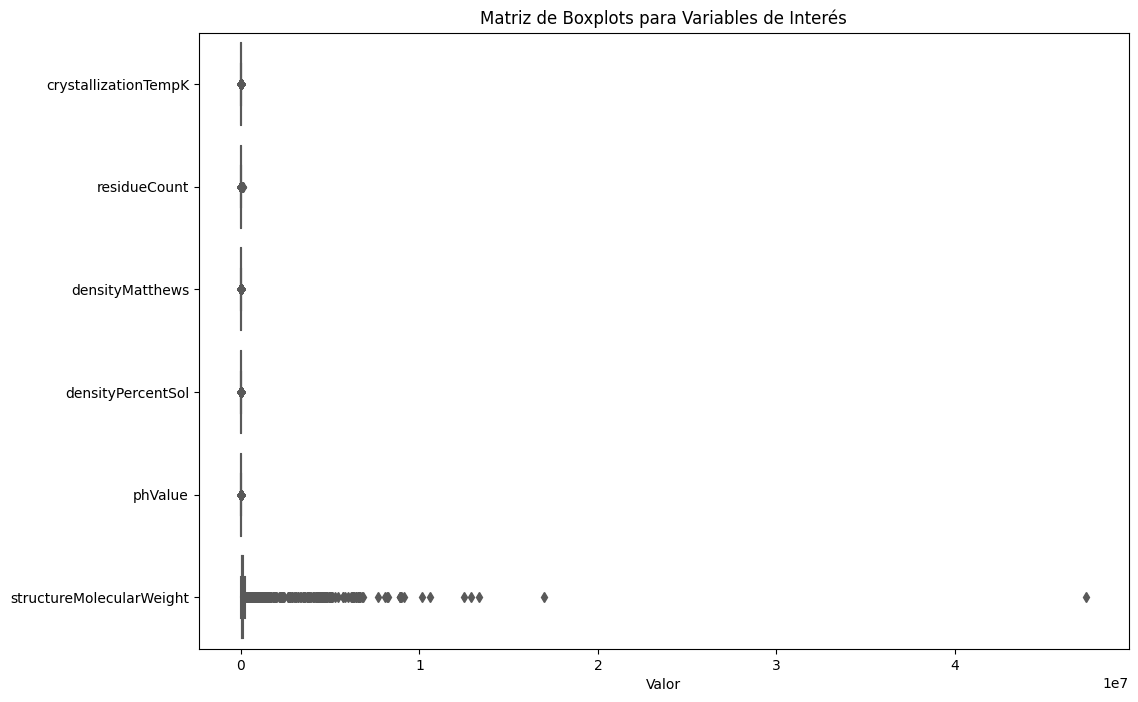

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Variables de interés
variables_of_interest = ["crystallizationTempK", "residueCount", "densityMatthews", "densityPercentSol", "phValue", "structureMolecularWeight"]

# Crear una matriz de características (X) con las variables de interés
X = df[variables_of_interest]

# Definir el tamaño del gráfico
plt.figure(figsize=(12, 8))

# Crear una matriz de boxplots
sns.boxplot(data=X, orient="h", palette="Set2")

# Añadir etiquetas y título
plt.xlabel("Valor")
plt.title("Matriz de Boxplots para Variables de Interés")

# Mostrar el gráfico
plt.show()


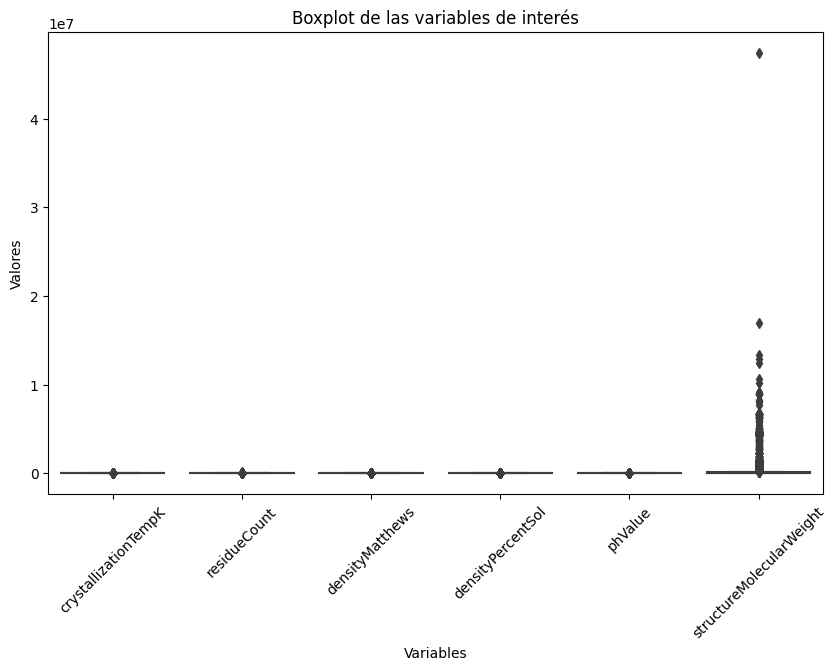

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Variables de interés
variables_of_interest = ["crystallizationTempK", "residueCount", "densityMatthews", "densityPercentSol", "phValue", "structureMolecularWeight"]

# Crear una matriz de características (X) con las variables de interés
X = df[variables_of_interest]

# Crear el boxplot
plt.figure(figsize=(10, 6))  # Tamaño de la figura
sns.boxplot(data=X)  # Crear el boxplot con los datos de X
plt.xticks(rotation=45)  # Rotar las etiquetas del eje x para mayor legibilidad
plt.title("Boxplot de las variables de interés")  # Título del gráfico
plt.xlabel("Variables")  # Etiqueta del eje x
plt.ylabel("Valores")  # Etiqueta del eje y
plt.show()  # Mostrar el gráfico


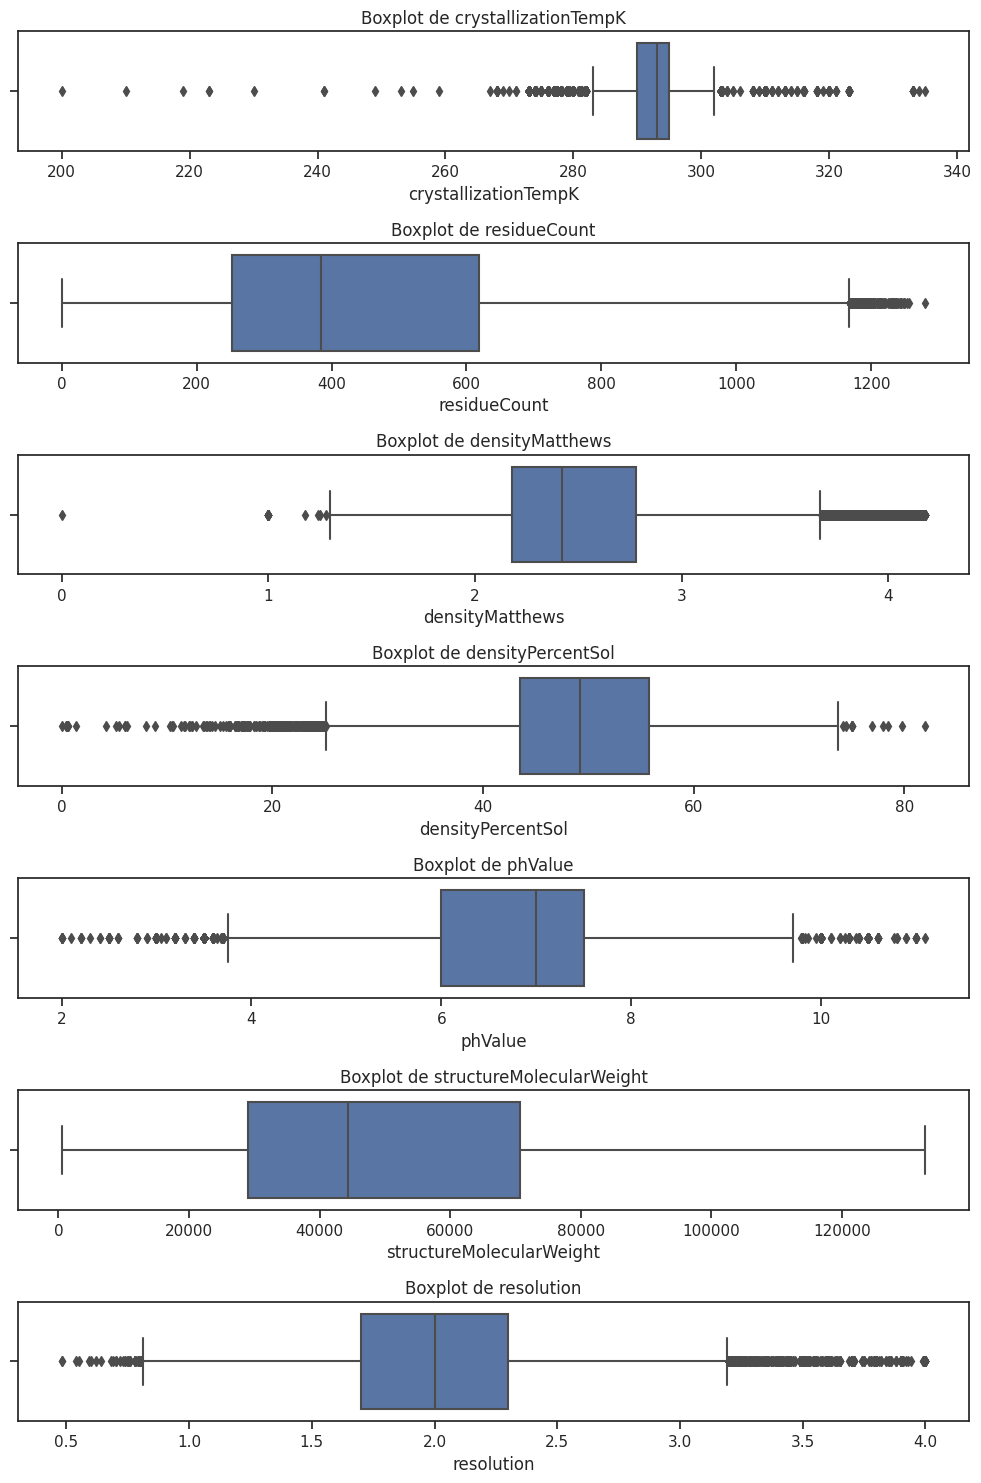

In [ ]:

variables_of_interest = ["crystallizationTempK", "residueCount", "densityMatthews", "densityPercentSol", "phValue", "structureMolecularWeight", "resolution"]
X = df[variables_of_interest]
# Crear una figura y ejes con matplotlib

fig, axs = plt.subplots(nrows=len(variables_of_interest), figsize=(10, 15))

# Para cada variable de interés, crea un boxplot en un eje separado
for i, var in enumerate(variables_of_interest):
    sns.boxplot(x=X[var], ax=axs[i])
    axs[i].set_title('Boxplot de ' + var)

# Ajustar el layout
plt.tight_layout()
plt.show()


In [ ]:
X = df[["crystallizationTempK", "residueCount", "densityMatthews",  "phValue", "resolution"]]

# Crear la variable objetivo (y) que es "Carga (Unidades)"
y = df['structureMolecularWeight']

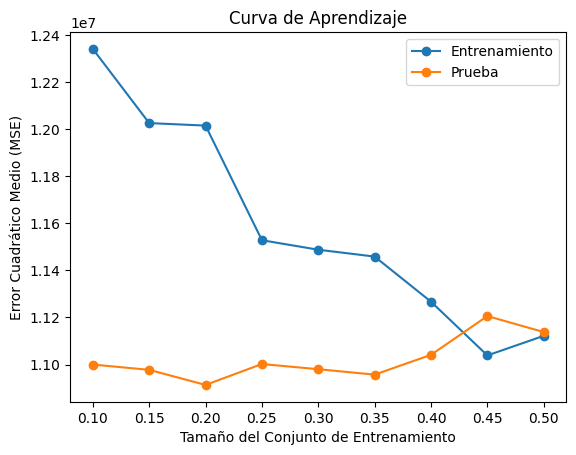

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Variables de interés
X = df[["crystallizationTempK", "residueCount", "densityMatthews", "phValue", "resolution"]]

# Variable objetivo
y = df['structureMolecularWeight']

# Divide los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear un modelo de regresión lineal múltiple
modelo = LinearRegression()

# Almacena los errores cuadráticos medios en entrenamiento y prueba
train_errors = []
test_errors = []

# Define una serie de tamaños de conjunto de entrenamiento
train_sizes = np.linspace(0.1, 0.5, 9)

for train_size in train_sizes:
    # Divide los datos en conjuntos de entrenamiento y prueba con el tamaño actual
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1 - train_size, random_state=42)

    # Crea y ajusta el modelo de regresión lineal
    modelo.fit(X_train, y_train)

    # Calcula el error cuadrático medio en entrenamiento y prueba
    y_train_pred = modelo.predict(X_train)
    y_test_pred = modelo.predict(X_test)
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    train_errors.append(train_mse)
    test_errors.append(test_mse)

# Grafica la curva de aprendizaje
plt.plot(train_sizes, train_errors, label='Entrenamiento', marker='o')
plt.plot(train_sizes, test_errors, label='Prueba', marker='o')
plt.xlabel('Tamaño del Conjunto de Entrenamiento')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.legend()
plt.title('Curva de Aprendizaje')
plt.show()


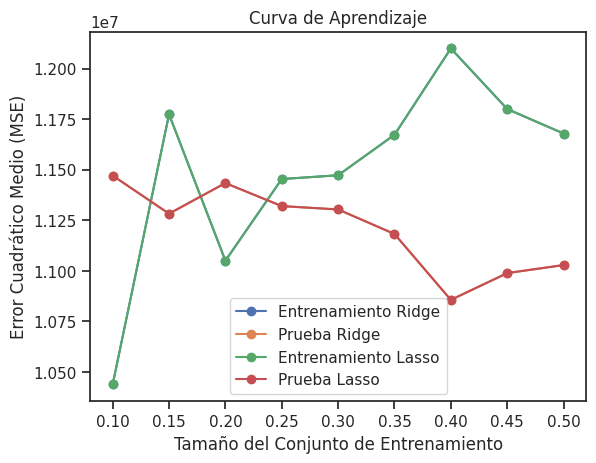

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Variables de interés
X = df[["crystallizationTempK", "residueCount", "densityMatthews", "phValue", "resolution"]]

# Variable objetivo
y = df['structureMolecularWeight']

# Define una serie de tamaños de conjunto de entrenamiento
train_sizes = np.linspace(0.1, 0.5, 9)

# Para cada modelo
for model_name, Model in [("Ridge", Ridge), ("Lasso", Lasso)]:
    # Almacena los errores cuadráticos medios en entrenamiento y prueba
    train_errors = []
    test_errors = []

    for train_size in train_sizes:
        # Divide los datos en conjuntos de entrenamiento y prueba con el tamaño actual
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1 - train_size, random_state=42)

        # Crea y ajusta el modelo
        modelo = Model()
        modelo.fit(X_train, y_train)

        # Calcula el error cuadrático medio en entrenamiento y prueba
        y_train_pred = modelo.predict(X_train)
        y_test_pred = modelo.predict(X_test)
        train_mse = mean_squared_error(y_train, y_train_pred)
        test_mse = mean_squared_error(y_test, y_test_pred)

        train_errors.append(train_mse)
        test_errors.append(test_mse)

    # Grafica la curva de aprendizaje
    plt.plot(train_sizes, train_errors, label=f'Entrenamiento {model_name}', marker='o')
    plt.plot(train_sizes, test_errors, label=f'Prueba {model_name}', marker='o')

plt.xlabel('Tamaño del Conjunto de Entrenamiento')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.legend()
plt.title('Curva de Aprendizaje')
plt.show()

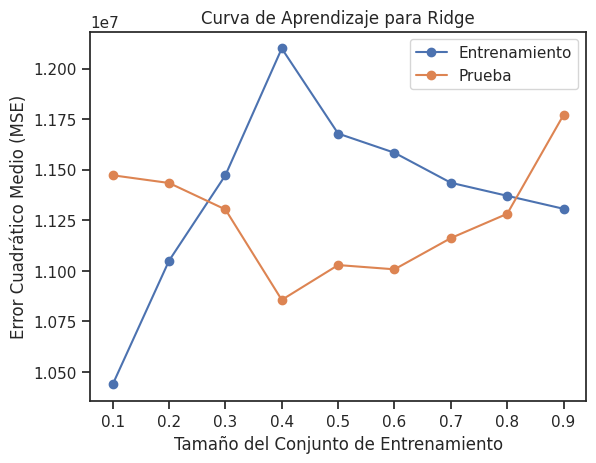

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Variables de interés
X = df[["crystallizationTempK", "residueCount", "densityMatthews", "phValue", "resolution"]]

# Variable objetivo
y = df['structureMolecularWeight']

# Almacena los errores cuadráticos medios en entrenamiento y prueba
train_errors = []
test_errors = []

# Define una serie de tamaños de conjunto de entrenamiento
train_sizes = np.linspace(0.1, 0.9, 9)

for train_size in train_sizes:
    # Divide los datos en conjuntos de entrenamiento y prueba con el tamaño actual
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1 - train_size, random_state=42)

    # Crea y ajusta el modelo Ridge
    modelo = Ridge(alpha=30.01835813575586)
    modelo.fit(X_train, y_train)

    # Calcula el error cuadrático medio en entrenamiento y prueba
    y_train_pred = modelo.predict(X_train)
    y_test_pred = modelo.predict(X_test)
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    train_errors.append(train_mse)
    test_errors.append(test_mse)

# Grafica la curva de aprendizaje
plt.plot(train_sizes, train_errors, label='Entrenamiento', marker='o')
plt.plot(train_sizes, test_errors, label='Prueba', marker='o')
plt.xlabel('Tamaño del Conjunto de Entrenamiento')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.legend()
plt.title('Curva de Aprendizaje para Ridge')
plt.show()

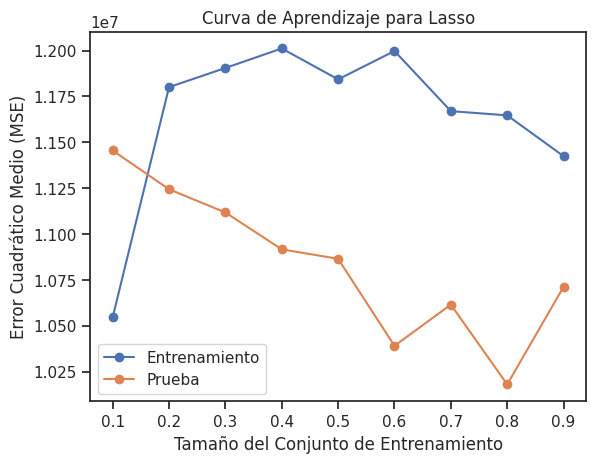

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Variables de interés
X = df[["crystallizationTempK", "residueCount", "densityMatthews", "phValue", "resolution"]]

# Variable objetivo
y = df['structureMolecularWeight']

# Almacena los errores cuadráticos medios en entrenamiento y prueba
train_errors = []
test_errors = []

# Define una serie de tamaños de conjunto de entrenamiento
train_sizes = np.linspace(0.1, 0.9, 9)

for train_size in train_sizes:
    # Divide los datos en conjuntos de entrenamiento y prueba con el tamaño actual
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1 - train_size, random_state=7)

    # Crea y ajusta el modelo Lasso
    modelo = Lasso()
    modelo.fit(X_train, y_train)

    # Calcula el error cuadrático medio en entrenamiento y prueba
    y_train_pred = modelo.predict(X_train)
    y_test_pred = modelo.predict(X_test)
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    train_errors.append(train_mse)
    test_errors.append(test_mse)

# Grafica la curva de aprendizaje
plt.plot(train_sizes, train_errors, label='Entrenamiento', marker='o')
plt.plot(train_sizes, test_errors, label='Prueba', marker='o')
plt.xlabel('Tamaño del Conjunto de Entrenamiento')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.legend()
plt.title('Curva de Aprendizaje para Lasso')
plt.show()

El valor óptimo de alpha es: 0.13354515629298974


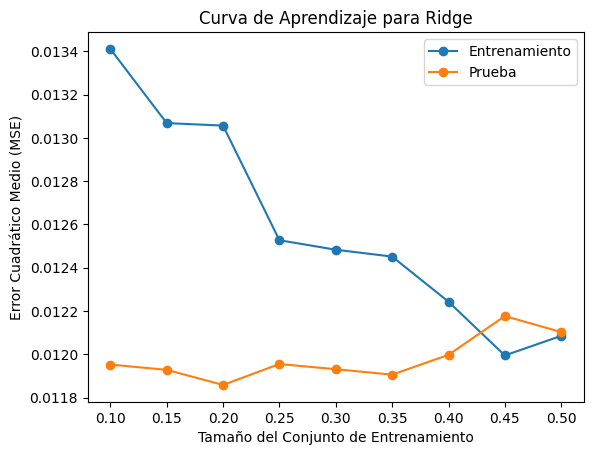

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error


# Almacena los errores cuadráticos medios en entrenamiento y prueba
train_errors = []
test_errors = []

# Define una serie de tamaños de conjunto de entrenamiento
train_sizes = np.linspace(0.1, 0.5, 9)

# Define una serie de valores de alpha para probar
alphas = np.logspace(-6, 6, 200)

for train_size in train_sizes:
    # Divide los datos en conjuntos de entrenamiento y prueba con el tamaño actual
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1 - train_size, random_state=42)

    # Crea y ajusta el modelo RidgeCV
    modelo = RidgeCV(alphas=alphas)
    modelo.fit(X_train, y_train)

    # Calcula el error cuadrático medio en entrenamiento y prueba
    y_train_pred = modelo.predict(X_train)
    y_test_pred = modelo.predict(X_test)
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    train_errors.append(train_mse)
    test_errors.append(test_mse)

# Imprime el valor óptimo de alpha
print(f'El valor óptimo de alpha es: {modelo.alpha_}')

# Grafica la curva de aprendizaje
plt.plot(train_sizes, train_errors, label='Entrenamiento', marker='o')
plt.plot(train_sizes, test_errors, label='Prueba', marker='o')
plt.xlabel('Tamaño del Conjunto de Entrenamiento')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.legend()
plt.title('Curva de Aprendizaje para Ridge')
plt.show()

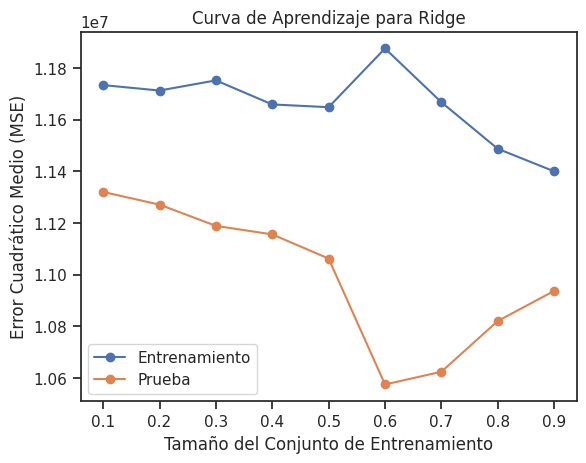

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Variables de interés
X = df[["crystallizationTempK", "residueCount", "densityMatthews", "phValue", "resolution"]]

# Variable objetivo
y = df['structureMolecularWeight']

# Almacena los errores cuadráticos medios en entrenamiento y prueba
train_errors = []
test_errors = []

# Define una serie de tamaños de conjunto de entrenamiento
train_sizes = np.linspace(0.1, 0.9, 9)

for train_size in train_sizes:
    # Divide los datos en conjuntos de entrenamiento y prueba con el tamaño actual
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1 - train_size, random_state=2)

    # Crea y ajusta el modelo Ridge con un valor de alpha específico
    modelo = Ridge(alpha=30.01835813575586)
    modelo.fit(X_train, y_train)

    # Calcula el error cuadrático medio en entrenamiento y prueba
    y_train_pred = modelo.predict(X_train)
    y_test_pred = modelo.predict(X_test)
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    train_errors.append(train_mse)
    test_errors.append(test_mse)

# Grafica la curva de aprendizaje
plt.plot(train_sizes, train_errors, label='Entrenamiento', marker='o')
plt.plot(train_sizes, test_errors, label='Prueba', marker='o')
plt.xlabel('Tamaño del Conjunto de Entrenamiento')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.legend()
plt.title('Curva de Aprendizaje para Ridge')
plt.show()


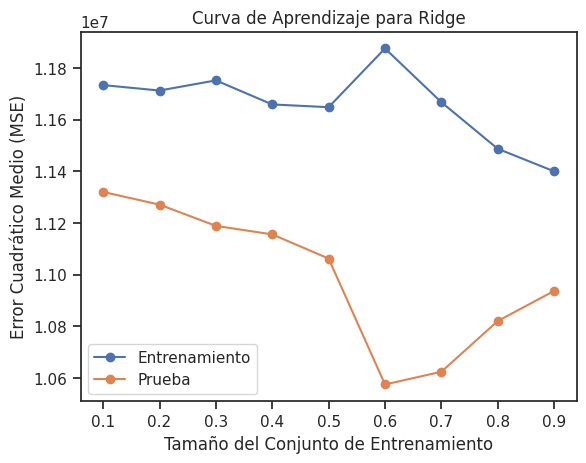

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Variables de interés
X = df[["crystallizationTempK", "residueCount", "densityMatthews", "phValue", "resolution"]]

# Variable objetivo
y = df['structureMolecularWeight']

# Almacena los errores cuadráticos medios en entrenamiento y prueba
train_errors = []
test_errors = []

# Define una serie de tamaños de conjunto de entrenamiento
train_sizes = np.linspace(0.1, 0.9, 9)

for train_size in train_sizes:
    # Divide los datos en conjuntos de entrenamiento y prueba con el tamaño actual
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1 - train_size, random_state=2)

    # Crea y ajusta el modelo Ridge con un valor de alpha específico
    modelo = Ridge(alpha=30.01835813575586)
    modelo.fit(X_train, y_train)

    # Calcula el error cuadrático medio en entrenamiento y prueba
    y_train_pred = modelo.predict(X_train)
    y_test_pred = modelo.predict(X_test)
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    train_errors.append(train_mse)
    test_errors.append(test_mse)

# Grafica la curva de aprendizaje
plt.plot(train_sizes, train_errors, label='Entrenamiento', marker='o')
plt.plot(train_sizes, test_errors, label='Prueba', marker='o')
plt.xlabel('Tamaño del Conjunto de Entrenamiento')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.legend()
plt.title('Curva de Aprendizaje para Ridge')
plt.show()


In [ ]:
from sklearn.preprocessing import StandardScaler

# Variables de interés
X = df[["crystallizationTempK", "residueCount", "densityMatthews", "phValue", "resolution"]]

# Variable objetivo
y = df['structureMolecularWeight']

# Crea el estandarizador
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Estandariza los datos de entrenamiento y prueba
X = scaler_X.fit_transform(X)
y = scaler_y.fit_transform(y.values.reshape(-1, 1))

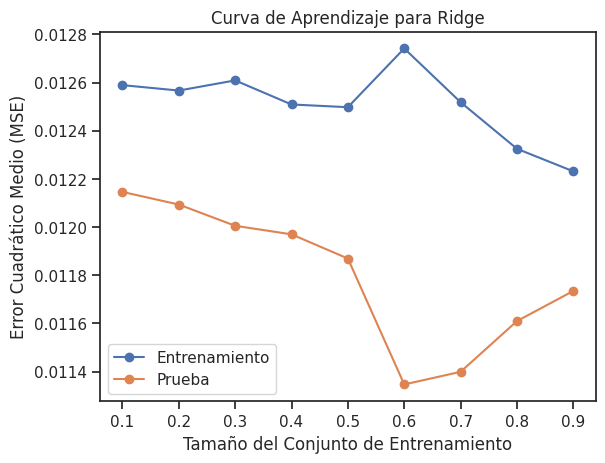

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

from sklearn.preprocessing import StandardScaler

from sklearn.preprocessing import StandardScaler

# Variables de interés
X = df[["crystallizationTempK", "residueCount", "densityMatthews", "phValue", "resolution"]]

# Variable objetivo
y = df['structureMolecularWeight']

# Crea el estandarizador
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Estandariza los datos de entrenamiento y prueba
X = scaler_X.fit_transform(X)
y = scaler_y.fit_transform(y.values.reshape(-1, 1))

# Almacena los errores cuadráticos medios en entrenamiento y prueba
train_errors = []
test_errors = []

# Define una serie de tamaños de conjunto de entrenamiento
train_sizes = np.linspace(0.1, 0.9, 9)

# Crea el estandarizador
scaler = StandardScaler()

for train_size in train_sizes:
    # Divide los datos en conjuntos de entrenamiento y prueba con el tamaño actual
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1 - train_size, random_state=2)



    # Crea y ajusta el modelo Ridge con un valor de alpha específico
    modelo = Ridge(alpha=0.13354515629298974)
    modelo.fit(X_train, y_train)

    # Calcula el error cuadrático medio en entrenamiento y prueba
    y_train_pred = modelo.predict(X_train)
    y_test_pred = modelo.predict(X_test)
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    train_errors.append(train_mse)
    test_errors.append(test_mse)

# Grafica la curva de aprendizaje
plt.plot(train_sizes, train_errors, label='Entrenamiento', marker='o')
plt.plot(train_sizes, test_errors, label='Prueba', marker='o')
plt.xlabel('Tamaño del Conjunto de Entrenamiento')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.legend()
plt.title('Curva de Aprendizaje para Ridge')
plt.show()

In [ ]:
print("Coeficientes del modelo:", modelo.coef_)


Coeficientes del modelo: [[-1.00171444e-03  9.86778014e-01  4.91098807e-03 -4.91854469e-04
   1.95891403e-02]]


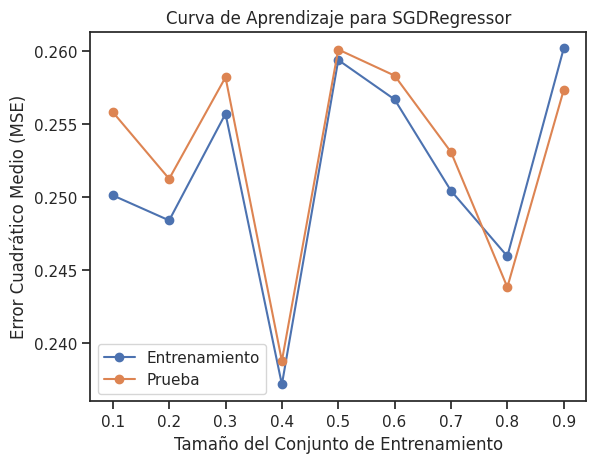

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# Variables de interés
X = df[["crystallizationTempK", "residueCount", "densityMatthews", "phValue", "resolution"]]

# Variable objetivo
y = df['structureMolecularWeight']

# Crea el estandarizador
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Estandariza los datos de entrenamiento y prueba
X = scaler_X.fit_transform(X)
y = scaler_y.fit_transform(y.values.reshape(-1, 1))

# Almacena los errores cuadráticos medios en entrenamiento y prueba
train_errors = []
test_errors = []

# Define una serie de tamaños de conjunto de entrenamiento
train_sizes = np.linspace(0.1, 0.9, 9)

for train_size in train_sizes:
    # Divide los datos en conjuntos de entrenamiento y prueba con el tamaño actual
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1 - train_size, random_state=2)

    # Crea y ajusta el modelo SGDRegressor con un valor de alpha específico
    modelo = SGDRegressor(alpha=1)
    modelo.fit(X_train, y_train.ravel())

    # Calcula el error cuadrático medio en entrenamiento y prueba
    y_train_pred = modelo.predict(X_train)
    y_test_pred = modelo.predict(X_test)
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    train_errors.append(train_mse)
    test_errors.append(test_mse)

# Grafica la curva de aprendizaje
plt.plot(train_sizes, train_errors, label='Entrenamiento', marker='o')
plt.plot(train_sizes, test_errors, label='Prueba', marker='o')
plt.xlabel('Tamaño del Conjunto de Entrenamiento')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.legend()
plt.title('Curva de Aprendizaje para SGDRegressor')
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# Variables de interés
X = df[["crystallizationTempK", "residueCount", "densityMatthews", "phValue", "resolution"]]

# Variable objetivo
y = df['structureMolecularWeight']

# Crea el estandarizador
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Estandariza los datos de entrenamiento y prueba
X = scaler_X.fit_transform(X)
y = scaler_y.fit_transform(y.values.reshape(-1, 1))

# Divide los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crea y ajusta el modelo RidgeCV para encontrar el valor óptimo de alpha
modelo = RidgeCV(alphas=np.logspace(-3, 3, 7))
modelo.fit(X_train, y_train)

# Obtiene el valor óptimo de alpha
alpha_optimo = modelo.alpha_

# Calcula el error cuadrático medio en entrenamiento y prueba con el valor óptimo de alpha
y_train_pred = modelo.predict(X_train)
y_test_pred = modelo.predict(X_test)
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

# Grafica la curva de aprendizaje
plt.plot(modelo.alphas, modelo.cv_values_.mean(axis=0))
plt.axvline(x=alpha_optimo, color='r', linestyle='--', label='Alpha óptimo')
plt.xlabel('Alpha')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.xscale('log')
plt.legend()
plt.title('Curva de Validación para Ridge')
plt.show()

print("El valor óptimo de alpha es:", alpha_optimo)
print("El error cuadrático medio en entrenamiento es:", train_mse)
print("El error cuadrático medio en prueba es:", test_mse)


AttributeError: ignored

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# Variables de interés
X = df[["crystallizationTempK", "residueCount", "densityMatthews", "phValue", "resolution"]]

# Variable objetivo
y = df['structureMolecularWeight']

# Crea el estandarizador
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Estandariza los datos de entrenamiento y prueba
X = scaler_X.fit_transform(X)
y = scaler_y.fit_transform(y.values.reshape(-1, 1))

# Almacena los errores cuadráticos medios en entrenamiento y prueba
train_errors = []
test_errors = []

# Define una serie de tamaños de conjunto de entrenamiento
train_sizes = np.linspace(0.1, 0.5, 9)

# Define los valores de alpha a probar
param_grid = {'alpha': np.logspace(-20, 10, 6)}

for train_size in train_sizes:
    # Divide los datos en conjuntos de entrenamiento y prueba con el tamaño actual
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1 - train_size, random_state=2)

    # Crea y ajusta el modelo SGDRegressor con un valor de alpha específico
    modelo = SGDRegressor()
    grid_search = GridSearchCV(modelo, param_grid, cv=5)
    grid_search.fit(X_train, y_train.ravel())
    modelo = grid_search.best_estimator_

    # Calcula el error cuadrático medio en entrenamiento y prueba
    y_train_pred = modelo.predict(X_train)
    y_test_pred = modelo.predict(X_test)
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    train_errors.append(train_mse)
    test_errors.append(test_mse)

# Grafica la curva de aprendizaje
plt.plot(train_sizes, train_errors, label='Entrenamiento', marker='o')
plt.plot(train_sizes, test_errors, label='Prueba', marker='o')
plt.xlabel('Tamaño del Conjunto de Entrenamiento')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.legend()
plt.title('Curva de Aprendizaje para SGDRegressor')
plt.show()

ValueError: ignored

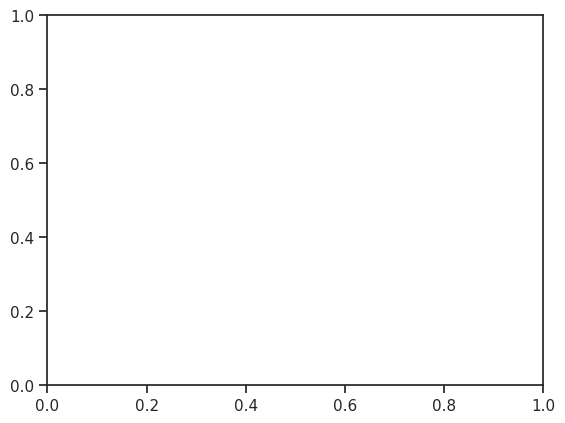

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# Variables de interés
X = df[["crystallizationTempK", "residueCount", "densityMatthews", "phValue", "resolution"]]

# Variable objetivo
y = df['structureMolecularWeight']

# Crea el estandarizador
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Estandariza los datos de entrenamiento y prueba
X = scaler_X.fit_transform(X)
y = scaler_y.fit_transform(y.values.reshape(-1, 1))

# Almacena los errores cuadráticos medios en entrenamiento y prueba
train_errors = []
test_errors = []

# Define una serie de tamaños de conjunto de entrenamiento
train_sizes = np.linspace(0.1, 0.9, 9)

# Define los valores de alpha a probar
param_grid = {'alpha': np.logspace(-20, 10, 6)}

for train_size in train_sizes:
    # Divide los datos en conjuntos de entrenamiento y prueba con el tamaño actual
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1 - train_size, random_state=2)

    # Crea y ajusta el modelo SGDRegressor con un valor de alpha específico
    modelo = SGDRegressor()
    grid_search = GridSearchCV(modelo, param_grid, cv=5)
    grid_search.fit(X_train, y_train.ravel())
    modelo = grid_search.best_estimator_

    # Obtiene el valor óptimo de alpha
    alpha_optimo = modelo.alpha

    # Calcula el error cuadrático medio en entrenamiento y prueba
    y_train_pred = modelo.predict(X_train)
    y_test_pred = modelo.predict(X_test)
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    train_errors.append(train_mse)
    test_errors.append(test_mse)

    # Grafica la curva de aprendizaje
    plt.plot(train_sizes, train_errors, label='Entrenamiento', marker='o')
    plt.plot(train_sizes, test_errors, label='Prueba', marker='o')
    plt.xlabel('Tamaño del Conjunto de Entrenamiento')
    plt.ylabel('Error Cuadrático Medio (MSE)')
    plt.legend()
    plt.title('Curva de Aprendizaje para SGDRegressor')
    plt.show()

    print("El valor óptimo de alpha es:", alpha_optimo)
    print("El error cuadrático medio en entrenamiento es:", train_mse)
    print("El error cuadrático medio en prueba es:", test_mse)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# Variables de interés
X = df[["crystallizationTempK", "residueCount", "densityMatthews", "phValue", "resolution"]]

# Variable objetivo
y = df['structureMolecularWeight']

# Crea el estandarizador
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Estandariza los datos de entrenamiento y prueba
X = scaler_X.fit_transform(X)
y = scaler_y.fit_transform(y.values.reshape(-1, 1))

# Almacena los errores cuadráticos medios en entrenamiento y prueba
train_errors = []
test_errors = []

# Define una serie de tamaños de conjunto de entrenamiento
train_sizes = np.linspace(0.1, 0.9, 9)

# Define los valores de alpha a probar
param_grid = {'alpha': np.logspace(-20, 10, 6)}

for train_size in train_sizes:
    # Divide los datos en conjuntos de entrenamiento y prueba con el tamaño actual
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1 - train_size, random_state=2)

    # Crea y ajusta el modelo MLPRegressor con un valor de alpha específico
    modelo = MLPRegressor(max_iter=1000)
    grid_search = GridSearchCV(modelo, param_grid, cv=5)
    grid_search.fit(X_train, y_train.ravel())
    modelo = grid_search.best_estimator_

    # Calcula el error cuadrático medio en entrenamiento y prueba
    y_train_pred = modelo.predict(X_train)
    y_test_pred = modelo.predict(X_test)
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    train_errors.append(train_mse)
    test_errors.append(test_mse)

# Grafica la curva de aprendizaje
plt.plot(train_sizes, train_errors, label='Entrenamiento', marker='o')
plt.plot(train_sizes, test_errors, label='Prueba', marker='o')
plt.xlabel('Tamaño del Conjunto de Entrenamiento')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.legend()
plt.title('Curva de Aprendizaje para MLPRegressor')
plt.show()

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:693: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:693: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:693: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:693: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


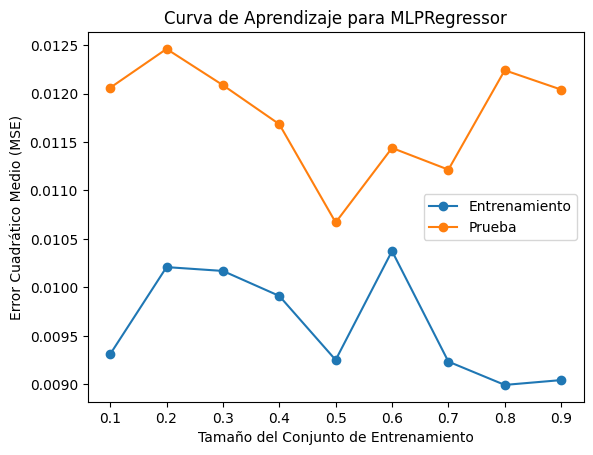

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# Variables de interés
X = df[["crystallizationTempK", "residueCount", "densityMatthews", "phValue", "resolution"]]

# Variable objetivo
y = df['structureMolecularWeight']

# Crea el estandarizador
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Estandariza los datos de entrenamiento y prueba
X = scaler_X.fit_transform(X)
y = scaler_y.fit_transform(y.values.reshape(-1, 1))

# Almacena los errores cuadráticos medios en entrenamiento y prueba
train_errors = []
test_errors = []

# Define una serie de tamaños de conjunto de entrenamiento
train_sizes = np.linspace(0.1, 0.9, 9)

for train_size in train_sizes:
    # Divide los datos en conjuntos de entrenamiento y prueba con el tamaño actual
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1 - train_size, random_state=2)

    # Crea y ajusta el modelo MLPRegressor con 5 capas ocultas y un número específico de iteraciones
    modelo = MLPRegressor(hidden_layer_sizes=(100, 100, 100, 100, 100), max_iter=1000)
    modelo.fit(X_train, y_train.ravel())

    # Calcula el error cuadrático medio en entrenamiento y prueba
    y_train_pred = modelo.predict(X_train)
    y_test_pred = modelo.predict(X_test)
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    train_errors.append(train_mse)
    test_errors.append(test_mse)

# Grafica la curva de aprendizaje
plt.plot(train_sizes, train_errors, label='Entrenamiento', marker='o')
plt.plot(train_sizes, test_errors, label='Prueba', marker='o')
plt.xlabel('Tamaño del Conjunto de Entrenamiento')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.legend()
plt.title('Curva de Aprendizaje para MLPRegressor')
plt.show()

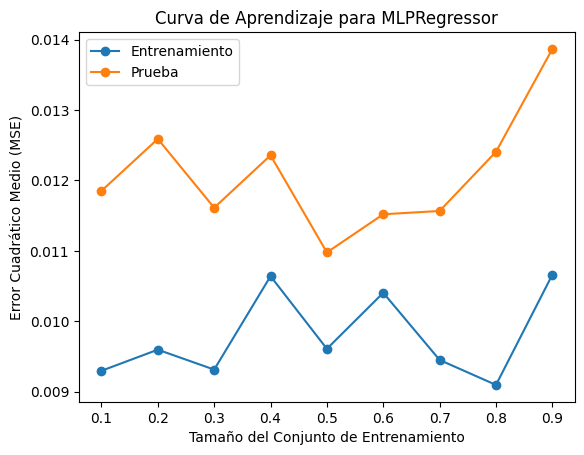

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# Variables de interés
X = df[["crystallizationTempK", "residueCount", "densityMatthews", "phValue", "resolution"]]

# Variable objetivo
y = df['structureMolecularWeight']

# Crea el estandarizador
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Estandariza los datos de entrenamiento y prueba
X = scaler_X.fit_transform(X)
y = scaler_y.fit_transform(y.values.reshape(-1, 1))

# Almacena los errores cuadráticos medios en entrenamiento y prueba
train_errors = []
test_errors = []

# Define una serie de tamaños de conjunto de entrenamiento
train_sizes = np.linspace(0.1, 0.9, 9)

for train_size in train_sizes:
    # Divide los datos en conjuntos de entrenamiento y prueba con el tamaño actual
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1 - train_size, random_state=2)

    # Crea y ajusta el modelo MLPRegressor con 5 capas ocultas y un número específico de iteraciones
    modelo = MLPRegressor(hidden_layer_sizes=(100, 100, 100, 100, 100,100,100,100,100,100), max_iter=1000)
    modelo.fit(X_train, y_train.ravel())

    # Calcula el error cuadrático medio en entrenamiento y prueba
    y_train_pred = modelo.predict(X_train)
    y_test_pred = modelo.predict(X_test)
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    train_errors.append(train_mse)
    test_errors.append(test_mse)

# Grafica la curva de aprendizaje
plt.plot(train_sizes, train_errors, label='Entrenamiento', marker='o')
plt.plot(train_sizes, test_errors, label='Prueba', marker='o')
plt.xlabel('Tamaño del Conjunto de Entrenamiento')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.legend()
plt.title('Curva de Aprendizaje para MLPRegressor')
plt.show()

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, SimpleRNN
from sklearn.metrics import mean_squared_error

# Define una serie de tamaños de conjunto de entrenamiento
train_sizes = np.linspace(0.1, 0.9, 9)

# Almacena los errores cuadráticos medios en entrenamiento
train_errors = []

for train_size in train_sizes:
    # Divide los datos en conjuntos de entrenamiento y prueba con el tamaño actual
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1 - train_size, random_state=2)

    # Crea el modelo
    modelo = Sequential()

    # Añade una capa RNN
    modelo.add(SimpleRNN(50, activation='relu', input_shape=(X_train.shape[1], 1)))

    # Añade una capa de salida
    modelo.add(Dense(1))

    # Compila el modelo
    modelo.compile(optimizer='adam', loss='mean_squared_error')

    # Ajusta el modelo a los datos de entrenamiento
    history = modelo.fit(X_train, y_train, epochs=100, verbose=0)

    # Almacena el error cuadrático medio en entrenamiento
    train_errors.append(history.history['loss'][-1])

# Grafica la curva de aprendizaje
plt.plot(train_sizes, train_errors, label='Entrenamiento', marker='o')
plt.xlabel('Tamaño del Conjunto de Entrenamiento')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.legend()
plt.title('Curva de Aprendizaje para RNN')
plt.show()

KeyboardInterrupt: ignored

In [ ]:
# Variables de interés
X = df[["crystallizationTempK", "residueCount", "densityMatthews", "phValue", "resolution"]]

# Variable objetivo
y = df['structureMolecularWeight']

# Crea el estandarizador
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Estandariza los datos de entrenamiento y prueba
X = scaler_X.fit_transform(X)
y = scaler_y.fit_transform(y.values.reshape(-1, 1))

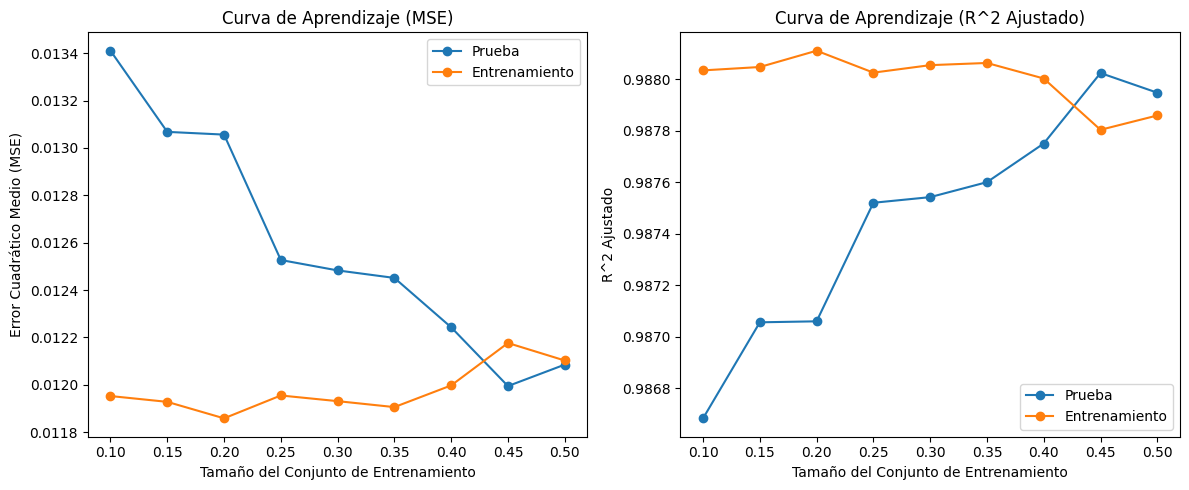

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
# Variables de interés
X = df[["crystallizationTempK", "residueCount", "densityMatthews", "phValue", "resolution"]]

# Variable objetivo
y = df['structureMolecularWeight']

# Crea el estandarizador
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Estandariza los datos de entrenamiento y prueba
X = scaler_X.fit_transform(X)
y = scaler_y.fit_transform(y.values.reshape(-1, 1))

# Divide los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear un modelo de regresión lineal múltiple
modelo = LinearRegression()

# Almacena los errores cuadráticos medios en entrenamiento y prueba
train_errors = []
test_errors = []
r2_train = []
r2_test = []

# Define una serie de tamaños de conjunto de entrenamiento
train_sizes = np.linspace(0.1, 0.5, 9)

for train_size in train_sizes:
    # Divide los datos en conjuntos de entrenamiento y prueba con el tamaño actual
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1 - train_size, random_state=42)

    # Crea y ajusta el modelo de regresión lineal
    modelo.fit(X_train, y_train)

    # Calcula el error cuadrático medio en entrenamiento y prueba
    y_train_pred = modelo.predict(X_train)
    y_test_pred = modelo.predict(X_test)
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    # Calcula R^2 ajustado
    r2_train.append(1 - (1 - r2_score(y_train, y_train_pred)) * (len(y_train) - 1) / (len(y_train) - X_train.shape[1] - 1))
    r2_test.append(1 - (1 - r2_score(y_test, y_test_pred)) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1))

    train_errors.append(train_mse)
    test_errors.append(test_mse)

# Grafica la curva de aprendizaje
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_sizes, train_errors, label='Prueba', marker='o')
plt.plot(train_sizes, test_errors, label='Entrenamiento', marker='o')
plt.xlabel('Tamaño del Conjunto de Entrenamiento')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.legend()
plt.title('Curva de Aprendizaje (MSE)')

plt.subplot(1, 2, 2)
plt.plot(train_sizes, r2_train, label='Prueba', marker='o')
plt.plot(train_sizes, r2_test, label='Entrenamiento', marker='o')
plt.xlabel('Tamaño del Conjunto de Entrenamiento')
plt.ylabel('R^2 Ajustado')
plt.legend()
plt.title('Curva de Aprendizaje (R^2 Ajustado)')

plt.tight_layout()
plt.show()


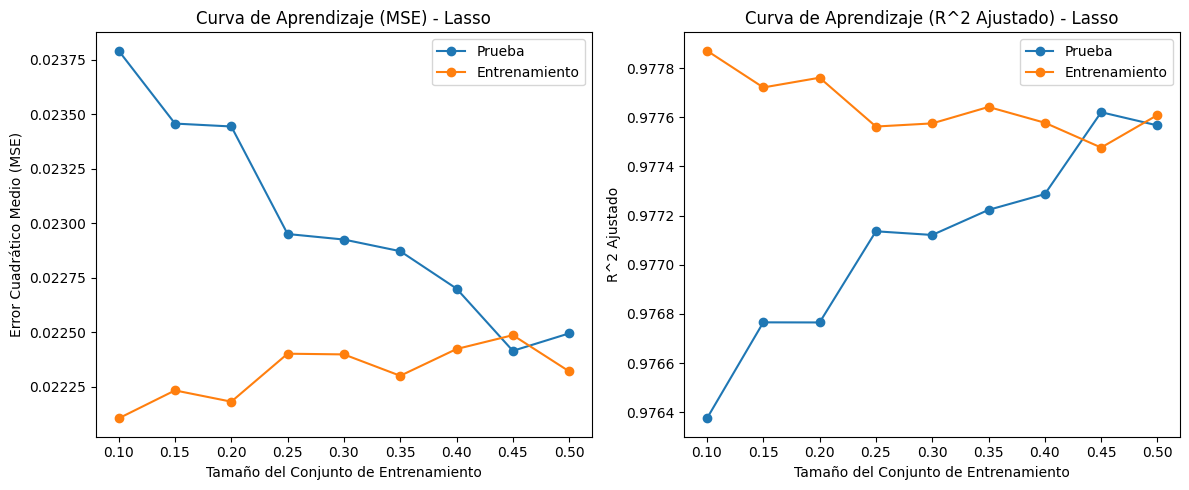

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Variables de interés
X = df[["crystallizationTempK", "residueCount", "densityMatthews", "phValue", "resolution"]]

# Variable objetivo
y = df['structureMolecularWeight']

# Crea el estandarizador
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Estandariza los datos de entrenamiento y prueba
X = scaler_X.fit_transform(X)
y = scaler_y.fit_transform(y.values.reshape(-1, 1))

# Divide los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear un modelo de regresión Lasso
modelo = Lasso(alpha=0.1)  # Ajusta el valor de alpha según sea necesario

# Almacena los errores cuadráticos medios en entrenamiento y prueba
train_errors = []
test_errors = []
r2_train = []
r2_test = []

# Define una serie de tamaños de conjunto de entrenamiento
train_sizes = np.linspace(0.1, 0.5, 9)

for train_size in train_sizes:
    # Divide los datos en conjuntos de entrenamiento y prueba con el tamaño actual
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1 - train_size, random_state=42)

    # Crea y ajusta el modelo de regresión Lasso
    modelo.fit(X_train, y_train)

    # Calcula el error cuadrático medio en entrenamiento y prueba
    y_train_pred = modelo.predict(X_train)
    y_test_pred = modelo.predict(X_test)
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    # Calcula R^2 ajustado
    r2_train.append(1 - (1 - r2_score(y_train, y_train_pred)) * (len(y_train) - 1) / (len(y_train) - X_train.shape[1] - 1))
    r2_test.append(1 - (1 - r2_score(y_test, y_test_pred)) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1))

    train_errors.append(train_mse)
    test_errors.append(test_mse)

# Grafica la curva de aprendizaje
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_sizes, train_errors, label='Prueba', marker='o')
plt.plot(train_sizes, test_errors, label='Entrenamiento', marker='o')
plt.xlabel('Tamaño del Conjunto de Entrenamiento')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.legend()
plt.title('Curva de Aprendizaje (MSE) - Lasso')

plt.subplot(1, 2, 2)
plt.plot(train_sizes, r2_train, label='Prueba', marker='o')
plt.plot(train_sizes, r2_test, label='Entrenamiento', marker='o')
plt.xlabel('Tamaño del Conjunto de Entrenamiento')
plt.ylabel('R^2 Ajustado')
plt.legend()
plt.title('Curva de Aprendizaje (R^2 Ajustado) - Lasso')

plt.tight_layout()
plt.show()


Alpha óptimo seleccionado: 1e-05


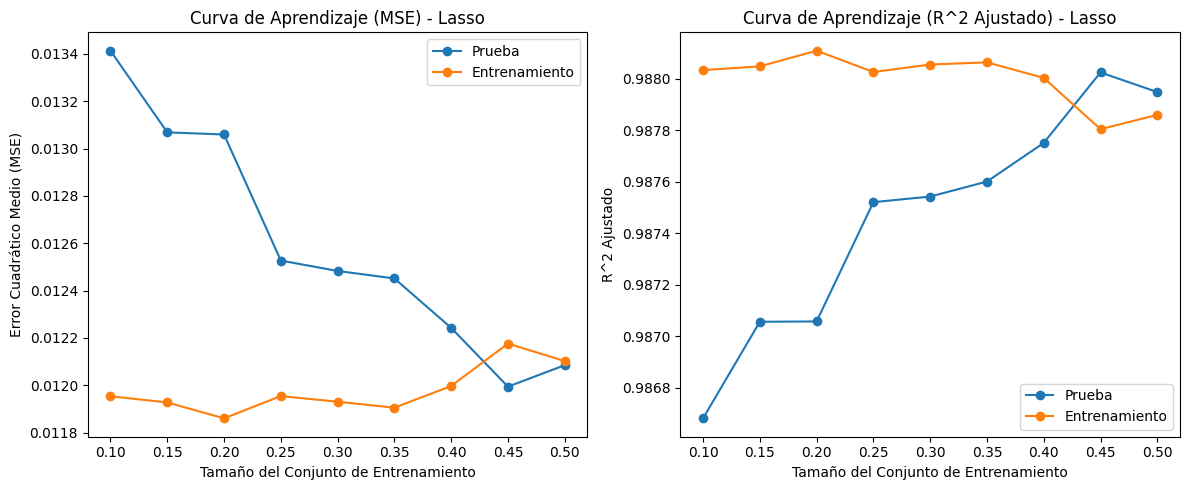

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Variables de interés
X = df[["crystallizationTempK", "residueCount", "densityMatthews", "phValue", "resolution"]]

# Variable objetivo
y = df['structureMolecularWeight']

# Crea el estandarizador
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Estandariza los datos de entrenamiento y prueba
X = scaler_X.fit_transform(X)
y = scaler_y.fit_transform(y.values.reshape(-1, 1))

# Divide los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear un modelo de regresión Lasso con validación cruzada para encontrar alpha óptimo
modelo = LassoCV(alphas=np.logspace(-6, 6, 13), cv=5)  # Ajusta el rango de alphas según sea necesario

# Ajusta el modelo automáticamente encuentra el alpha óptimo
modelo.fit(X_train, y_train.ravel())

# Imprime el alpha óptimo seleccionado
print(f'Alpha óptimo seleccionado: {modelo.alpha_}')

# Almacena los errores cuadráticos medios en entrenamiento y prueba
train_errors = []
test_errors = []
r2_train = []
r2_test = []

# Define una serie de tamaños de conjunto de entrenamiento
train_sizes = np.linspace(0.1, 0.5, 9)

for train_size in train_sizes:
    # Divide los datos en conjuntos de entrenamiento y prueba con el tamaño actual
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1 - train_size, random_state=42)

    # Crea y ajusta el modelo de regresión Lasso con el alpha óptimo
    modelo.alpha_ = modelo.alpha_
    modelo.fit(X_train, y_train.ravel())

    # Calcula el error cuadrático medio en entrenamiento y prueba
    y_train_pred = modelo.predict(X_train)
    y_test_pred = modelo.predict(X_test)
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    # Calcula R^2 ajustado
    r2_train.append(1 - (1 - r2_score(y_train, y_train_pred)) * (len(y_train) - 1) / (len(y_train) - X_train.shape[1] - 1))
    r2_test.append(1 - (1 - r2_score(y_test, y_test_pred)) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1))

    train_errors.append(train_mse)
    test_errors.append(test_mse)

# Grafica la curva de aprendizaje
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_sizes, train_errors, label='Prueba', marker='o')
plt.plot(train_sizes, test_errors, label='Entrenamiento', marker='o')
plt.xlabel('Tamaño del Conjunto de Entrenamiento')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.legend()
plt.title('Curva de Aprendizaje (MSE) - Lasso')

plt.subplot(1, 2, 2)
plt.plot(train_sizes, r2_train, label='Prueba', marker='o')
plt.plot(train_sizes, r2_test, label='Entrenamiento', marker='o')
plt.xlabel('Tamaño del Conjunto de Entrenamiento')
plt.ylabel('R^2 Ajustado')
plt.legend()
plt.title('Curva de Aprendizaje (R^2 Ajustado) - Lasso')

plt.tight_layout()
plt.show()


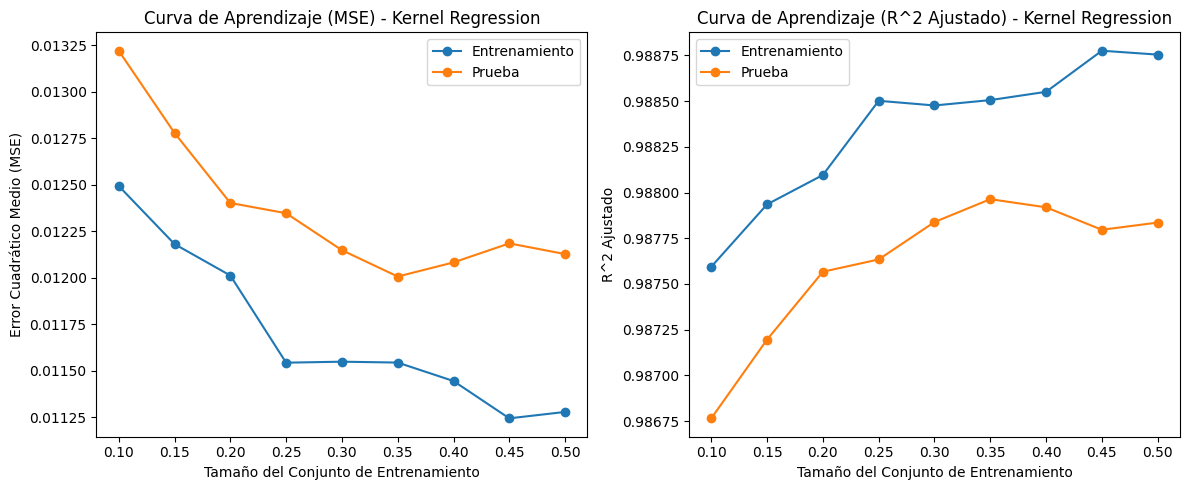

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Variables de interés
X = df[["crystallizationTempK", "residueCount", "densityMatthews", "phValue", "resolution"]]

# Variable objetivo
y = df['structureMolecularWeight']

# Crea el estandarizador
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Estandariza los datos de entrenamiento y prueba
X = scaler_X.fit_transform(X)
y = scaler_y.fit_transform(y.values.reshape(-1, 1))

# Divide los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear un modelo de regresión con kernel (SVR con kernel RBF)
modelo = SVR(kernel='rbf', C=1.0, epsilon=0.1)  # Ajusta los parámetros según sea necesario

# Almacena los errores cuadráticos medios en entrenamiento y prueba
train_errors = []
test_errors = []
r2_train = []
r2_test = []

# Define una serie de tamaños de conjunto de entrenamiento
train_sizes = np.linspace(0.1, 0.5, 9)

for train_size in train_sizes:
    # Divide los datos en conjuntos de entrenamiento y prueba con el tamaño actual
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1 - train_size, random_state=42)

    # Crea y ajusta el modelo de regresión con kernel
    modelo.fit(X_train, y_train.ravel())

    # Calcula el error cuadrático medio en entrenamiento y prueba
    y_train_pred = modelo.predict(X_train)
    y_test_pred = modelo.predict(X_test)
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    # Calcula R^2 ajustado
    r2_train.append(1 - (1 - r2_score(y_train, y_train_pred)) * (len(y_train) - 1) / (len(y_train) - X_train.shape[1] - 1))
    r2_test.append(1 - (1 - r2_score(y_test, y_test_pred)) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1))

    train_errors.append(train_mse)
    test_errors.append(test_mse)

# Grafica la curva de aprendizaje
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_sizes, train_errors, label='Entrenamiento', marker='o')
plt.plot(train_sizes, test_errors, label='Prueba', marker='o')
plt.xlabel('Tamaño del Conjunto de Entrenamiento')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.legend()
plt.title('Curva de Aprendizaje (MSE) - Kernel Regression')

plt.subplot(1, 2, 2)
plt.plot(train_sizes, r2_train, label='Prueba', marker='o')
plt.plot(train_sizes, r2_test, label='Entrenamiento', marker='o')
plt.xlabel('Tamaño del Conjunto de Entrenamiento')
plt.ylabel('R^2 Ajustado')
plt.legend()
plt.title('Curva de Aprendizaje (R^2 Ajustado) - Kernel Regression')

plt.tight_layout()
plt.show()


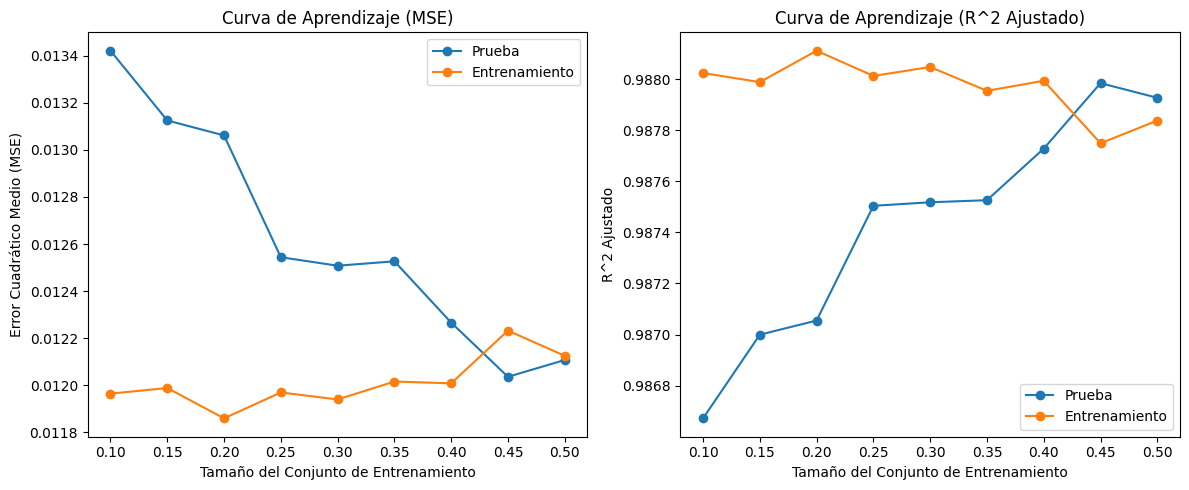

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Variables de interés
X = df[["crystallizationTempK", "residueCount", "densityMatthews", "phValue", "resolution"]]

# Variable objetivo
y = df['structureMolecularWeight']

# Crea el estandarizador
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Estandariza los datos de entrenamiento y prueba
X = scaler_X.fit_transform(X)
y = scaler_y.fit_transform(y.values.reshape(-1, 1))

# Divide los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Almacena los errores cuadráticos medios en entrenamiento y prueba
train_errors = []
test_errors = []
r2_train = []
r2_test = []

# Define una serie de tamaños de conjunto de entrenamiento
train_sizes = np.linspace(0.1, 0.5, 9)

for train_size in train_sizes:
    # Divide los datos en conjuntos de entrenamiento y prueba con el tamaño actual
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1 - train_size, random_state=42)

    # Crea el modelo de regresión lineal con SGD
    modelo = SGDRegressor(max_iter=1000, tol=1e-3, random_state=42)

    # Ajusta el modelo de regresión lineal con SGD
    modelo.fit(X_train, y_train.ravel())

    # Calcula el error cuadrático medio en entrenamiento y prueba
    y_train_pred = modelo.predict(X_train)
    y_test_pred = modelo.predict(X_test)
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    # Calcula R^2 ajustado
    r2_train.append(1 - (1 - r2_score(y_train, y_train_pred)) * (len(y_train) - 1) / (len(y_train) - X_train.shape[1] - 1))
    r2_test.append(1 - (1 - r2_score(y_test, y_test_pred)) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1))

    train_errors.append(train_mse)
    test_errors.append(test_mse)

# Grafica la curva de aprendizaje
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_sizes, train_errors, label='Prueba', marker='o')
plt.plot(train_sizes, test_errors, label='Entrenamiento', marker='o')
plt.xlabel('Tamaño del Conjunto de Entrenamiento')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.legend()
plt.title('Curva de Aprendizaje (MSE)')

plt.subplot(1, 2, 2)
plt.plot(train_sizes, r2_train, label='Prueba', marker='o')
plt.plot(train_sizes, r2_test, label='Entrenamiento', marker='o')
plt.xlabel('Tamaño del Conjunto de Entrenamiento')
plt.ylabel('R^2 Ajustado')
plt.legend()
plt.title('Curva de Aprendizaje (R^2 Ajustado)')

plt.tight_layout()
plt.show()



Model: "sequential_8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_9 (Dense)             (None, 64)                384       
                                                                 
 dense_10 (Dense)            (None, 32)                2080      
                                                                 
 dense_11 (Dense)            (None, 1)                 33        
                                                                 
Total params: 2497 (9.75 KB)
Trainable params: 2497 (9.75 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/50
1403/1403 [==============================] - 6s 4ms/step - loss: 0.0324 - mae: 0.0925 - val_loss: 0.0132 - val_mae: 0.0646
Epoch 2/50
1403/1403 [==============================] - 4s 3ms/step - loss: 0.0125 - mae: 0.0673 - val_loss: 0.0124 - val_mae: 0.0653
Epoch 3/50
1403/14

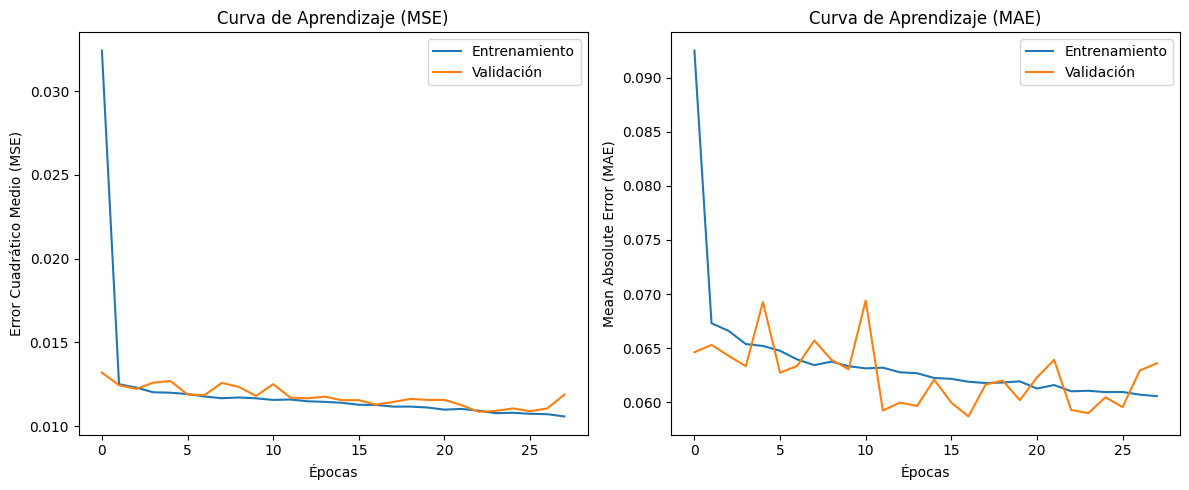

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Variables de interés
X = df[["crystallizationTempK", "residueCount", "densityMatthews", "phValue", "resolution"]]

# Variable objetivo
y = df['structureMolecularWeight']

# Crea el estandarizador
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Estandariza los datos de entrenamiento y prueba
X = scaler_X.fit_transform(X)
y = scaler_y.fit_transform(y.values.reshape(-1, 1))

# Divide los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crea el modelo de red neuronal
model = Sequential()
model.add(Dense(units=64, activation='relu', input_dim=X_train.shape[1]))
model.add(Dense(units=32, activation='relu'))
model.add(Dense(units=1, activation='linear'))

# Compila el modelo
model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error', metrics=['mae'])

# Muestra la arquitectura del modelo
model.summary()

# Entrena el modelo
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, callbacks=[EarlyStopping(patience=5)])

# Evalúa el modelo
loss, mae = model.evaluate(X_test, y_test)
print(f'Loss: {loss}, Mean Absolute Error: {mae}')

# Predice con el modelo
y_pred = model.predict(X_test)

# Transforma las predicciones de nuevo a la escala original
y_pred_inv = scaler_y.inverse_transform(y_pred)
y_test_inv = scaler_y.inverse_transform(y_test)

# Calcula métricas en la escala original
mse = mean_squared_error(y_test_inv, y_pred_inv)
r2 = r2_score(y_test_inv, y_pred_inv)

print(f'Mean Squared Error (original scale): {mse}')
print(f'R^2 Score (original scale): {r2}')

# Grafica la curva de aprendizaje
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.xlabel('Épocas')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.legend()
plt.title('Curva de Aprendizaje (MSE)')

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Entrenamiento')
plt.plot(history.history['val_mae'], label='Validación')
plt.xlabel('Épocas')
plt.ylabel('Mean Absolute Error (MAE)')
plt.legend()
plt.title('Curva de Aprendizaje (MAE)')

plt.tight_layout()
plt.show()


Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 3, 64)             256       
                                                                 
 flatten (Flatten)           (None, 192)               0         
                                                                 
 dense_8 (Dense)             (None, 1)                 193       
                                                                 
Total params: 449 (1.75 KB)
Trainable params: 449 (1.75 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/50
1403/1403 [==============================] - 15s 10ms/step - loss: 0.0478 - mae: 0.1038 - val_loss: 0.0127 - val_mae: 0.0643
Epoch 2/50
1403/1403 [==============================] - 8s 5ms/step - loss: 0.0122 - mae: 0.0646 - val_loss: 0.0127 - val_mae: 0.0666
Epoch 3/50
1403/14

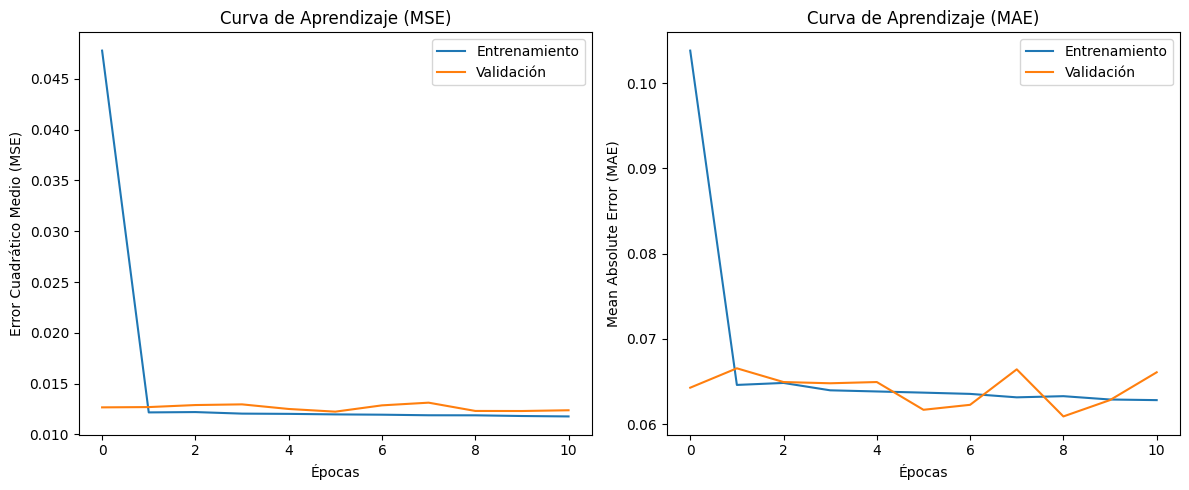

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Variables de interés
X = df[["crystallizationTempK", "residueCount", "densityMatthews", "phValue", "resolution"]]

# Variable objetivo
y = df['structureMolecularWeight']

# Crea el estandarizador
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Estandariza los datos de entrenamiento y prueba
X = scaler_X.fit_transform(X)
y = scaler_y.fit_transform(y.values.reshape(-1, 1))

# Divide los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Reshape de los datos para CNN (asumiendo que tienes una secuencia de longitud fija)
sequence_length = X_train.shape[1]
X_train_reshaped = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_reshaped = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Crea el modelo de red neuronal convolucional (CNN)
model = Sequential()
model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(sequence_length, 1)))
model.add(Flatten())
model.add(Dense(units=1, activation='linear'))

# Compila el modelo
model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error', metrics=['mae'])

# Muestra la arquitectura del modelo
model.summary()

# Entrena el modelo
history = model.fit(X_train_reshaped, y_train, epochs=50, batch_size=32, validation_split=0.2, callbacks=[EarlyStopping(patience=5)])

# Evalúa el modelo
loss, mae = model.evaluate(X_test_reshaped, y_test)
print(f'Loss: {loss}, Mean Absolute Error: {mae}')

# Predice con el modelo
y_pred = model.predict(X_test_reshaped)

# Transforma las predicciones de nuevo a la escala original
y_pred_inv = scaler_y.inverse_transform(y_pred)
y_test_inv = scaler_y.inverse_transform(y_test)

# Calcula métricas en la escala original
mse = mean_squared_error(y_test_inv, y_pred_inv)
r2 = r2_score(y_test_inv, y_pred_inv)

print(f'Mean Squared Error (original scale): {mse}')
print(f'R^2 Score (original scale): {r2}')

# Grafica la curva de aprendizaje
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.xlabel('Épocas')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.legend()
plt.title('Curva de Aprendizaje (MSE)')

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Entrenamiento')
plt.plot(history.history['val_mae'], label='Validación')
plt.xlabel('Épocas')
plt.ylabel('Mean Absolute Error (MAE)')
plt.legend()
plt.title('Curva de Aprendizaje (MAE)')

plt.tight_layout()
plt.show()
